In [1]:
import uproot
import matplotlib.pyplot as plt
import ROOT
from IPython.display import Image, display
import numpy as np
import mplhep as hep
import awkward as ak
hep.style.use("CMS")
import time
from concurrent.futures import ProcessPoolExecutor, as_completed

Welcome to JupyROOT 6.30/03


In [7]:
with open("/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v10Reco/250304_225945/filelist.txt") as f:
    fileList_QCD1000to1200 = f.read().splitlines()
with open("/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v10Reco/250304_225952/filelist.txt") as f:
    fileList_QCD1200to1500 = f.read().splitlines()
with open("/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v10Reco/250304_230000/filelist.txt") as f:
    fileList_QCD1500to2000 = f.read().splitlines()
with open("/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v10Reco/250304_230008/filelist.txt") as f:
    fileList_QCD2000 = f.read().splitlines()
    

processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v10Reco/250304_225932/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v10Reco/250304_225938/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v10Reco/250304_230017/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v10Reco/250304_230025/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v10Reco/250304_230032/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v10Reco/250304_230040/QCD-4Jets_Bin-HT-800to1000.root"],
               #"QCD1000to1200": fileList_QCD1000to1200,
               #"QCD1200to1500": fileList_QCD1200to1500,
               #"QCD1500to2000": fileList_QCD1500to2000,
               #"QCD2000": fileList_QCD2000}
                "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v10Reco/250304_225945/QCD-4Jets_Bin-HT-1000to1200.root"],
                "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v10Reco/250304_225952/QCD-4Jets_Bin-HT-1200to1500.root"],
                "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v10Reco/250304_230000/QCD-4Jets_Bin-HT-1500to2000.root"],
                "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v10Reco/250304_230008/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v10Reco/250304_225828/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v10Reco/250304_225846/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v10Reco/250304_225903/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v10Reco/250304_225920/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v10Reco/250304_225834/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v10Reco/250304_225852/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v10Reco/250304_225909/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v10Reco/250304_225926/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v10Reco/250304_225822/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v10Reco/250304_225839/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v10Reco/250304_225857/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v10Reco/250304_225915/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [3]:
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v10Scouting/250304_164853/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v10Scouting/250304_164901/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v10Scouting/250304_164943/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v10Scouting/250304_164952/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v10Scouting/250304_165000/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v10Scouting/250304_165009/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v10Scouting/250304_164909/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v10Scouting/250304_164917/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v10Scouting/250304_164926/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v10Scouting/250304_164935/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v10Scouting/250304_164731/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v10Scouting/250304_164754/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v10Scouting/250304_164816/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v10Scouting/250304_164838/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v10Scouting/250304_164738/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v10Scouting/250304_164802/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v10Scouting/250304_164823/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v10Scouting/250304_164845/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v10Scouting/250304_164722/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v10Scouting/250304_164746/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v10Scouting/250304_164809/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v10Scouting/250304_164830/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [2]:
#20 % FPR Track Selection Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v11Scout20TrackFPR/250321_155620/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout20TrackFPR/250321_155626/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v11Scout20TrackFPR/250321_155706/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v11Scout20TrackFPR/250321_155714/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v11Scout20TrackFPR/250321_155723/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v11Scout20TrackFPR/250321_155731/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v11Scout20TrackFPR/250321_155634/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v11Scout20TrackFPR/250321_155641/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v11Scout20TrackFPR/250321_155649/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v11Scout20TrackFPR/250321_155657/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v11Scout20TrackFPR/250321_155503/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v11Scout20TrackFPR/250321_155523/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v11Scout20TrackFPR/250321_155543/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v11Scout20TrackFPR/250321_155604/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v11Scout20TrackFPR/250321_155510/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v11Scout20TrackFPR/250321_155529/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v11Scout20TrackFPR/250321_155550/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v11Scout20TrackFPR/250321_155611/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v11Scout20TrackFPR/250321_155456/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v11Scout20TrackFPR/250321_155517/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v11Scout20TrackFPR/250321_155536/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v11Scout20TrackFPR/250321_155556/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [4]:
#30 % FPR Track Selection Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v11Scout30TrackFPR/250323_123549/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout30TrackFPR/250323_123555/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v11Scout30TrackFPR/250323_123630/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v11Scout30TrackFPR/250323_123637/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v11Scout30TrackFPR/250323_123645/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v11Scout30TrackFPR/250323_123652/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v11Scout30TrackFPR/250323_123602/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v11Scout30TrackFPR/250323_123609/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v11Scout30TrackFPR/250323_123615/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v11Scout30TrackFPR/250323_123623/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v11Scout30TrackFPR/250323_123442/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v11Scout30TrackFPR/250323_123459/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v11Scout30TrackFPR/250323_123518/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v11Scout30TrackFPR/250323_123536/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v11Scout30TrackFPR/250323_123448/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v11Scout30TrackFPR/250323_123505/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v11Scout30TrackFPR/250323_123523/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v11Scout30TrackFPR/250323_123542/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v11Scout30TrackFPR/250323_123435/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v11Scout30TrackFPR/250323_123454/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v11Scout30TrackFPR/250323_123512/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v11Scout30TrackFPR/250323_123530/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [2]:
#10 % FPR Track Selection Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v11Scout10TrackFPR/250323_200428/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout10TrackFPR/250323_200434/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v11Scout10TrackFPR/250323_200507/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v11Scout10TrackFPR/250323_200513/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v11Scout10TrackFPR/250323_200520/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v11Scout10TrackFPR/250323_200527/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v11Scout10TrackFPR/250323_200441/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v11Scout10TrackFPR/250323_200447/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v11Scout10TrackFPR/250323_200454/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v11Scout10TrackFPR/250323_200500/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v11Scout10TrackFPR/250323_200326/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v11Scout10TrackFPR/250323_200343/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v11Scout10TrackFPR/250323_200400/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v11Scout10TrackFPR/250323_200416/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v11Scout10TrackFPR/250323_200332/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v11Scout10TrackFPR/250323_200349/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v11Scout10TrackFPR/250323_200405/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v11Scout10TrackFPR/250323_200422/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v11Scout10TrackFPR/250323_200320/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v11Scout10TrackFPR/250323_200338/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v11Scout10TrackFPR/250323_200355/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v11Scout10TrackFPR/250323_200411/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v11Scout30TrackFPR/250323_123549/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v11Scout30TrackFPR/250323_123630/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v11Scout30TrackFPR/250323_123637/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v11Scout30TrackFPR/250323_123652/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout30TrackFPR/250323_123555/TTtoLNu2Q.root

Processing /eos/cms/store/group/phys_exotica/DVSco

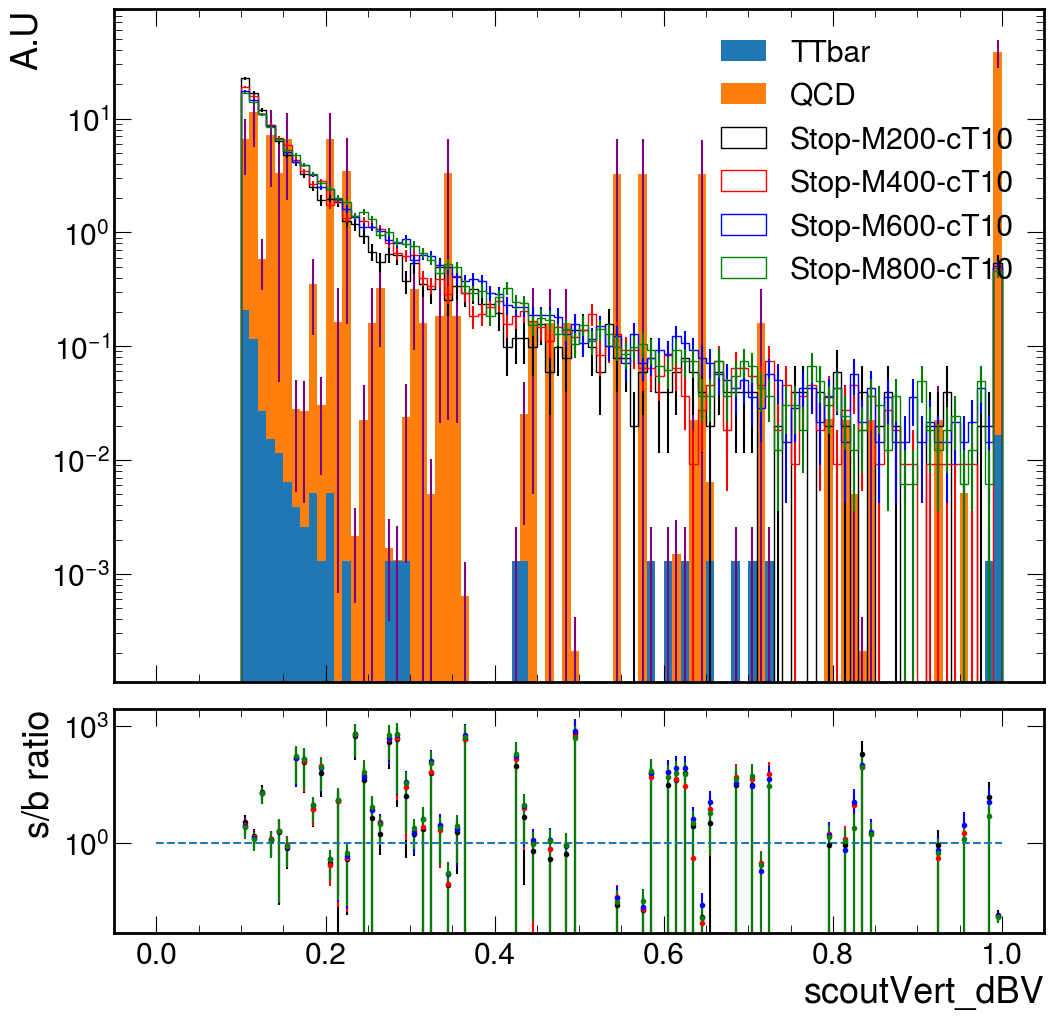

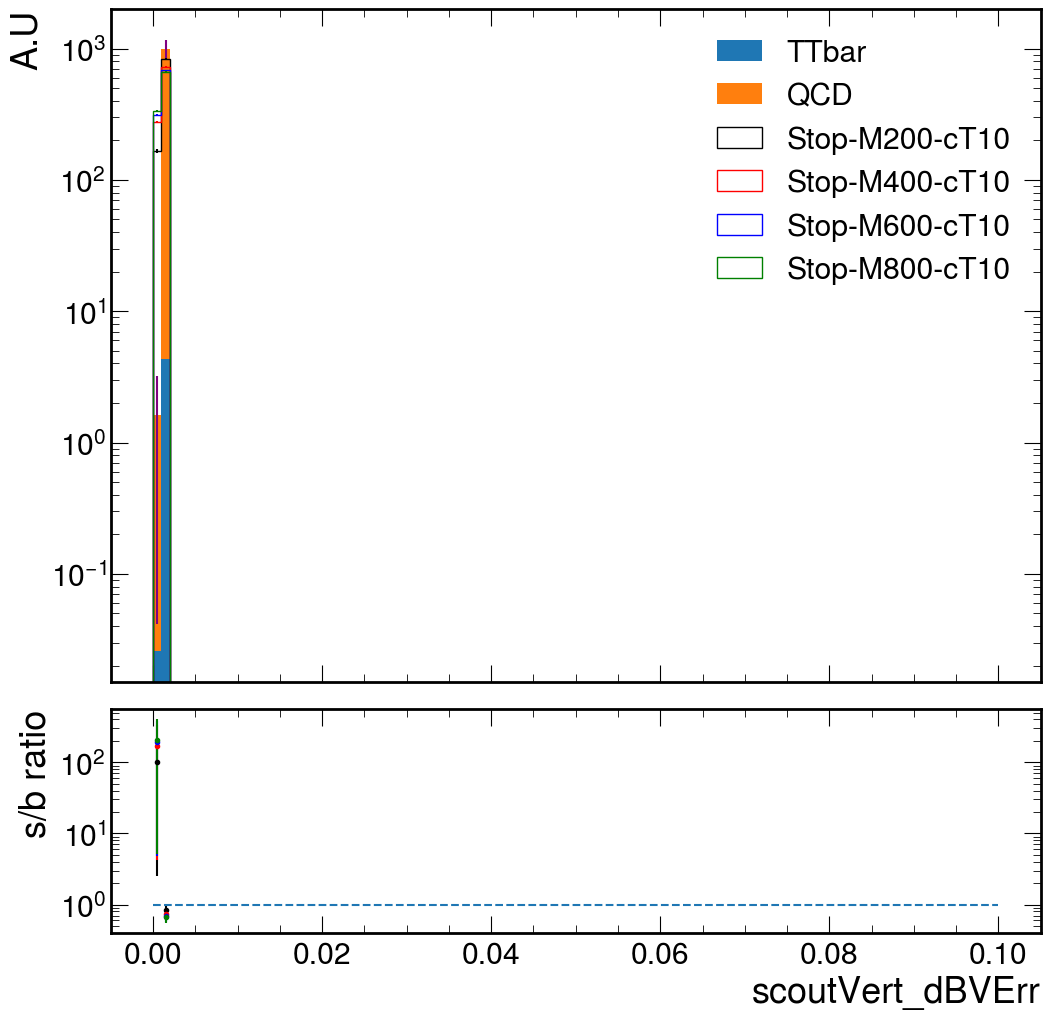

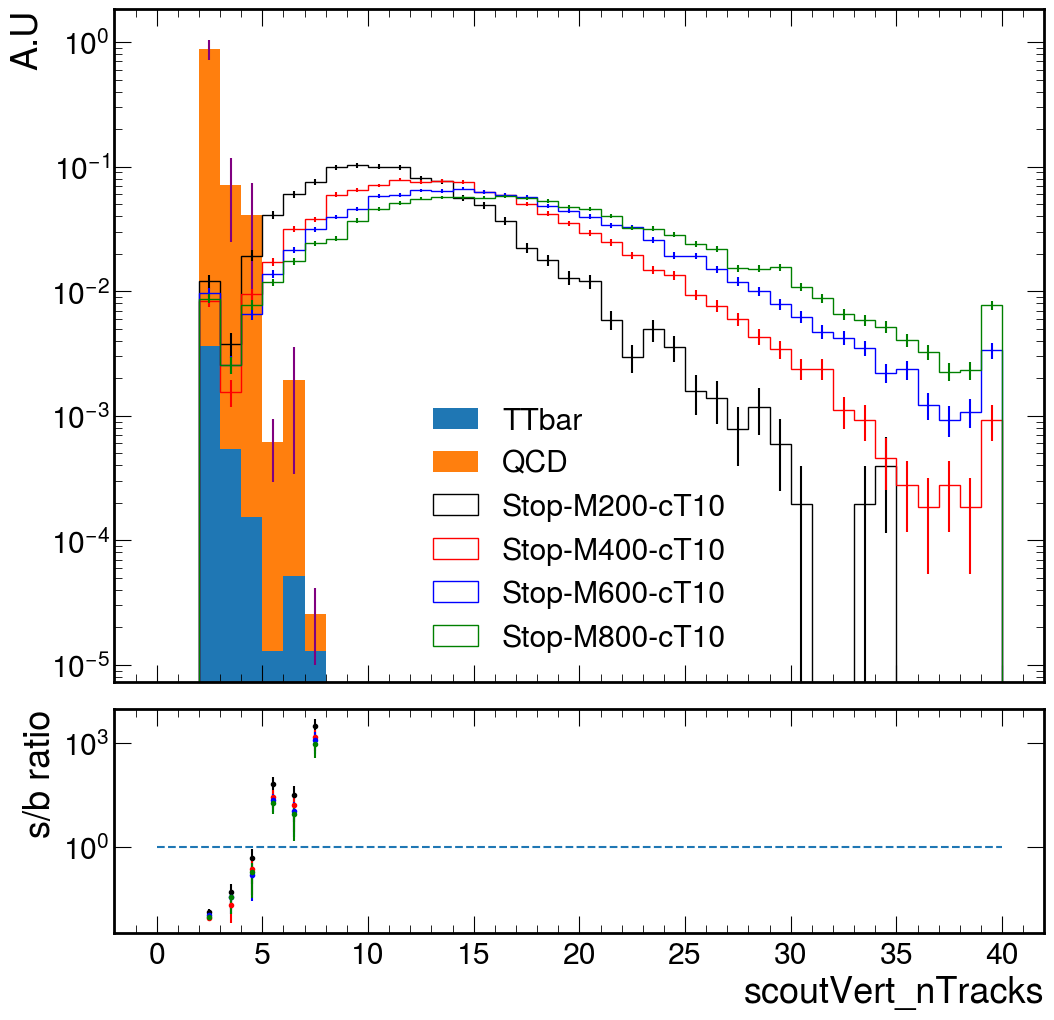

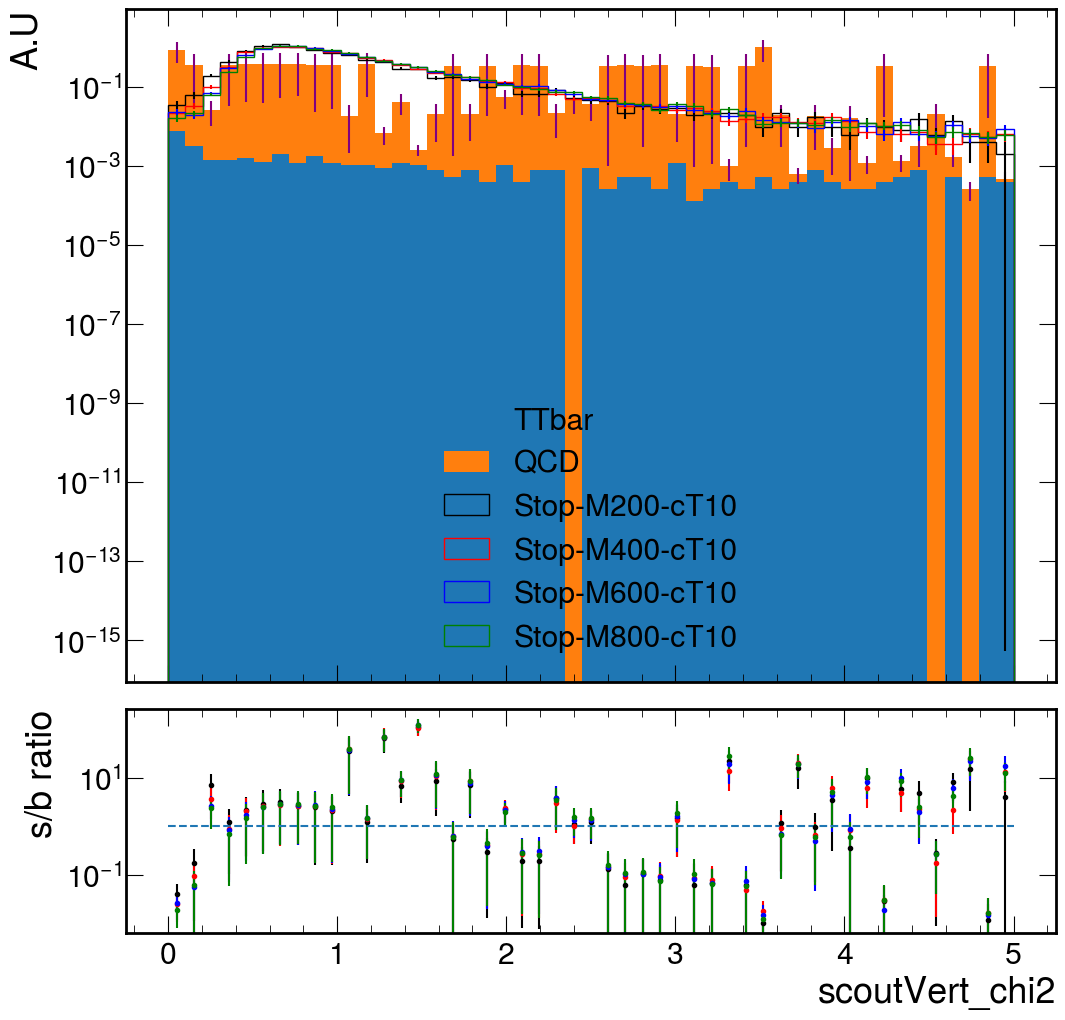

Total runtime: 6.25 seconds


In [22]:
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    #"vertTrack_pt": [0,50,101], "vertTrack_eta": [-3,3,101], "vertTrack_phi": [-3.142,3.142,101],
    #"vertTrack_reducedChi2": [0,7,51], "vertTrack_dxy": [0,0.3,51], "vertTrack_dxySig": [0,50,101],
    #"vertTrack_nValidPixelHits": [0,13,14], "vertTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"vertTrack_nValidStripHits": [0,32,33], 
    "scoutVert_dBV": [0,1,101], "scoutVert_dBVErr": [0,0.1,101],
    #"vertTrack_nMissingInnerHits": [0,5,6], 
    "scoutVert_nTracks": [0,40,41], "scoutVert_chi2": [0,5,50]
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["vertTrack_iVtx", "weight"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum

            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]

                # Apply displacement cut
                if "vertTrack" in plot:
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
                elif "scoutVert" in plot:
                    mask = (batch["scoutVert_dBV"] >= 0.1) & (batch["scoutVert_dBVErr"] < 0.002)
                else:
                    mask = ak.ones_like(data, dtype=bool)
                data = data[mask]
                #mask = ak.sum(mask,axis=1)>1
                #data = data[mask]
                #maskedWeights = weights[mask]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]
for plot in plotDict.keys():
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights[plot][process] = sigPlotWeights[plot][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights[f"{plot}_squared"][process] = sigPlotWeights[f"{plot}_squared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=["TTbar","QCD"], bins=bins)

    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
               bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    #bgValues = np.nan_to_num(bgValues)
    #bgErrors = np.nan_to_num(bgErrors)
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
    
    colors = {"Stop-M200-cT10": "black", "Stop-M400-cT10": "red", "Stop-M600-cT10": "blue", "Stop-M800-cT10": "green"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)

        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
        ratioValues = sigValues / bgValues
        ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
        #ratioValues = np.nan_to_num(ratioValues)
        #ratioErrors = np.nan_to_num(ratioErrors)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

    rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
    rax.set_ylabel("s/b ratio")
    ax.set_ylabel("A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    rax.set_yscale("log")
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


In [15]:
#Cutflow table script 
doPercents = True
bin_namesCustom = ["$\delta d_{BV}<0.002$","8Tracks"]

def process_cutflows(args):
    """ Process a single ROOT file in chunks using uproot.iterate() """
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output[process] = {}
        output[process+"_squared"] = {}
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = ["scoutVert_dBV","scoutVert_dBVErr", "scoutVert_nTracks","weight"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        weightSum = [0]*len(bin_namesCustom)
        weightSumSquared = [0] * len(bin_namesCustom)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # event weights
            data = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            mask = ak.sum(data>=0.1,axis=1)>0
            weights = weights[mask]
            data = data[mask]
            ntracks = ntracks[mask]
            #weightSum[0] += ak.sum(weights)
            #weightSumSquared[0] += ak.sum(weights**2)
            
            # Apply displacement error cut
            mask = batch["scoutVert_dBVErr"][mask] < 0.002
            data = data[mask]
            ntracks = ntracks[mask]
            
            mask = ak.sum(data>=0.1,axis=1)>0
            weights = weights[mask]
            data = data[mask]
            ntracks = ntracks[mask]
            weightSum[0] += ak.sum(weights)
            weightSumSquared[0] += ak.sum(weights**2)
            
            mask = ntracks > 7
            data = data[mask]
            mask = ak.sum(data>=0.1,axis=1)>0
            weights = weights[mask]
            weightSum[1] += ak.sum(weights)
            weightSumSquared[1] += ak.sum(weights**2)
            
        for i in range(len(bin_namesCustom)):
            output[process][bin_namesCustom[i]] = weightSum[i]
            output[process+"_squared"][bin_namesCustom[i]] = weightSumSquared[i]
        
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    """ Process all ROOT files in parallel and aggregate results """
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_cutflows, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for process in result:
                if process not in results:
                    results[process] = result[process]
                else:
                    for cut in result[process]:
                        results[process][cut] = results[process].get(cut, 0) + result[process][cut]

    return results


# Define LaTeX table header
latex_table = "\\begin{table}[htbp]\n"
latex_table += "\\centering\n"

dict = signalDict | processDict
customWeights = parallel_processing(dict)

firstProcess = True
weightSumDict = {}
weightSquaredSumDict = {}
genWeightSumDict = {}
for process, rootFiles in dict.items():
    firstFile = True
    weightSum = []
    weightSquaredSum = []
    genWeightSum = 0
    for rootFile in rootFiles:
        f = ROOT.TFile.Open(rootFile, "READ")
        h_weightsSkim = f.Get("triggerFilter/weightsSkim")
        h_weightsSquaredSkim = f.Get("triggerFilter/weightsSquaredSkim")
        h_genWeights = f.Get("triggerFilter/genWeightsSkim")
        h_weights = f.Get("scoutingTree/weights")
        h_weightsSquared = f.Get("scoutingTree/weightsSquared")
        
        # Extract content
        n_bins = h_weights.GetNbinsX()
        weights = np.array([h_weights.GetBinContent(i) for i in range(3, n_bins)]) #temp since there are redundant cuts in tree maker, normally would go from 1 to n_bins+1
        bin_names = np.array([h_weights.GetXaxis().GetLabels().At(i-1).GetName() for i in range(3, n_bins)])
        weightsSquared = np.array([h_weightsSquared.GetBinContent(i) for i in range(3, n_bins)])
        
        n_binsSkim = h_weightsSkim.GetNbinsX() 
        weightsSkim = np.array([h_weightsSkim.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        bin_namesSkim = np.array([h_weightsSkim.GetXaxis().GetLabels().At(i-1).GetName() for i in range(1, n_binsSkim + 1)])
        weightsSquaredSkim = np.array([h_weightsSquaredSkim.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        genWeights = np.array([h_genWeights.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        
        if(firstFile and firstProcess):
            latex_table += "\\resizebox{\\textwidth}{!}{\\begin{tabular}{|l|"+(len(bin_names)+len(bin_namesSkim)+len(bin_namesCustom)+2)*"c|"+"}\n"
            latex_table += "\\hline\n"
            latex_table += "Process "
            for name in np.concatenate((bin_namesSkim,bin_names)):
                latex_table += "& {} ".format(name)
                weightSum.append(0)
                weightSquaredSum.append(0)
            for name in bin_namesCustom:
                latex_table += "& {} ".format(name)
            latex_table += "& {} & {} ".format("s/sqrt(s+b)","$\epsilon/(1+\sqrt{B})$")
            latex_table += "\\\\\n"
            latex_table += "\\hline\n"
            firstFile = False
        elif(firstFile):
            for name in np.concatenate((bin_namesSkim,bin_names)):
                weightSum.append(0)
                weightSquaredSum.append(0)
            firstFile = False

        genWeightSum += genWeights[0]
        for i in range(len(weightsSkim)):
            weightSum[i] += weightsSkim[i]
            weightSquaredSum[i] += weightsSquaredSkim[i]
        for i in range(len(weights)):
            weightSum[i+len(weightsSkim)] += weights[i]
            weightSquaredSum[i+len(weightsSkim)] += weightsSquared[i]
    firstProcess = False
    weightSumDict[process] = weightSum
    weightSquaredSumDict[process] = weightSquaredSum
    genWeightSumDict[process] = genWeightSum
      
#Combining Background Subprocesses and Reweighting Events
for process in dict.keys():
    for i in range(len(weightSumDict[process])):
        weightSumDict[process][i] = weightSumDict[process][i] / genWeightSumDict[process]
        weightSquaredSumDict[process][i] = weightSquaredSumDict[process][i] / (genWeightSumDict[process]**2)
    for cut in customWeights[process].keys():
        customWeights[process][cut] = customWeights[process][cut] / genWeightSumDict[process]
        customWeights[process+"_squared"][cut] = customWeights[process+"_squared"][cut] / (genWeightSumDict[process]**2)
weightSumDict["QCD"] = weightSumDict["QCD200to400"]
weightSquaredSumDict["QCD"] = weightSquaredSumDict["QCD200to400"]
weightSumDict["TTbar"] = weightSumDict["TTTo4Q"]
weightSquaredSumDict["TTbar"] = weightSquaredSumDict["TTTo4Q"]
for i in range(len(weightSumDict["QCD"])):
    weightSumDict["QCD"][i] = weightSumDict["QCD"][i]+weightSumDict["QCD400to600"][i]+weightSumDict["QCD600to800"][i]+weightSumDict["QCD800to1000"][i]+weightSumDict["QCD1000to1200"][i]+weightSumDict["QCD1200to1500"][i]+weightSumDict["QCD1500to2000"][i]+weightSumDict["QCD2000"][i]
    weightSquaredSumDict["QCD"][i] = weightSquaredSumDict["QCD"][i]+weightSquaredSumDict["QCD400to600"][i]+weightSquaredSumDict["QCD600to800"][i]+weightSquaredSumDict["QCD800to1000"][i]+weightSquaredSumDict["QCD1000to1200"][i]+weightSquaredSumDict["QCD1200to1500"][i]+weightSquaredSumDict["QCD1500to2000"][i]+weightSquaredSumDict["QCD2000"][i]
    weightSumDict["TTbar"][i] = weightSumDict["TTbar"][i]+weightSumDict["TTToLNu2Q"][i]
    weightSquaredSumDict["TTbar"][i] = weightSquaredSumDict["TTbar"][i]+weightSquaredSumDict["TTToLNu2Q"][i]
customWeights["QCD"] = {}
customWeights["TTbar"] = {}
customWeights["QCD_squared"] = {}
customWeights["TTbar_squared"] = {}
for i in range(len(bin_namesCustom)):
    cut = bin_namesCustom[i]
    customWeights["QCD"][cut] = customWeights["QCD200to400"][cut]+customWeights["QCD400to600"][cut]+customWeights["QCD600to800"][cut]+customWeights["QCD800to1000"][cut]+customWeights["QCD1000to1200"][cut]+customWeights["QCD1200to1500"][cut]+customWeights["QCD1500to2000"][cut]+customWeights["QCD2000"][cut]
    customWeights["QCD_squared"][cut] = customWeights["QCD200to400_squared"][cut]+customWeights["QCD400to600_squared"][cut]+customWeights["QCD600to800_squared"][cut]+customWeights["QCD800to1000_squared"][cut]+customWeights["QCD1000to1200_squared"][cut]+customWeights["QCD1200to1500_squared"][cut]+customWeights["QCD1500to2000_squared"][cut]+customWeights["QCD2000_squared"][cut]
    customWeights["TTbar"][cut] = customWeights["TTTo4Q"][cut]+customWeights["TTToLNu2Q"][cut]
    customWeights["TTbar_squared"][cut] = customWeights["TTTo4Q_squared"][cut]+customWeights["TTToLNu2Q_squared"][cut]

for process in list(signalDict.keys())+["TTbar","QCD"]:
    latex_table +=  f"{process}"
    for i in range(len(weightSumDict[process])):
        if(doPercents):
            latex_table +=  f" & {weightSumDict[process][i]/weightSumDict[process][0]:.3f}"
        else:    
            latex_table +=  f" & {weightSumDict[process][i]:.3E} $\pm$ {np.sqrt(weightSquaredSumDict[process][i]):.3E}"
    #Custom Cutflows
    for i in range(len(bin_namesCustom)):
        if(doPercents):
            latex_table +=  f" & {customWeights[process][bin_namesCustom[i]]/weightSumDict[process][0]:.3E}"
        else:    
            latex_table +=  f" & {customWeights[process][bin_namesCustom[i]]:.3E} $\pm$ {np.sqrt(customWeights[process+'_squared'][bin_namesCustom[i]]):.3E}"
    
    latex_table += "\\\\\n"
    

latex_table += "\\hline\n"
latex_table += "\\end{tabular}}\n"
latex_table += "\\caption{Cutflow table}\n"
latex_table += "\\label{tab:cutflow}\n"
latex_table += "\\end{table}"

#Add sensitivity

splitStrings = latex_table.split("\\hline\n")
processString = splitStrings[2]
substrings = processString.split("\\\\")
final_table = splitStrings[0]+"\\hline\n"+splitStrings[1]+"\\hline\n"
for string in substrings:
    process = string.split(' &')[0]
    process = process.replace('\n','')
    if(process in signalDict):
        if(len(bin_namesCustom)):
            string += f" & {customWeights[process][bin_namesCustom[-1]]/np.sqrt(customWeights[process][bin_namesCustom[-1]]+customWeights['QCD'][bin_namesCustom[-1]]+customWeights['TTbar'][bin_namesCustom[-1]]):.3E} & {(customWeights[process][bin_namesCustom[-1]]/weightSumDict[process][0])/(1+np.sqrt(customWeights['QCD'][bin_namesCustom[-1]]+customWeights['TTbar'][bin_namesCustom[-1]])):.3E}"
        else:
            string += f" & {weightSumDict[process][-1]/np.sqrt(weightSumDict[process][-1]+weightSumDict['QCD'][-1]+weightSumDict['TTbar'][-1]):.3E}" 
    elif(process in ["QCD","TTbar"]):
        string += f" & & "
    final_table += string + "\\\\"
final_table = final_table[:-2]
final_table += "\\hline\n" + splitStrings[3]

print(final_table)

Processing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v11Scout30TrackFPR/250323_123523/StopStopbarTo2Dbar2D_M-600_CTau-3mm.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v11Scout30TrackFPR/250323_123536/StopStopbarTo2Dbar2D_M-800_CTau-1mm.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v11Scout30TrackFPR/250323_123442/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout30TrackFPR/250323_123555/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v11Scout30TrackFPR/2

[0.002]
errCutValue 0.002
Processing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout30TrackFPR/250323_123555/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v11Scout30TrackFPR/250323_123549/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v11Scout30TrackFPR/250323_123652/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v11Scout30TrackFPR/250323_123602/QCD-4Jets_Bin-HT-1000to1200.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v11Scout30TrackFPR/250323_123609/QCD-4Jets_Bin-HT-1200to1500.rootProcessing /e

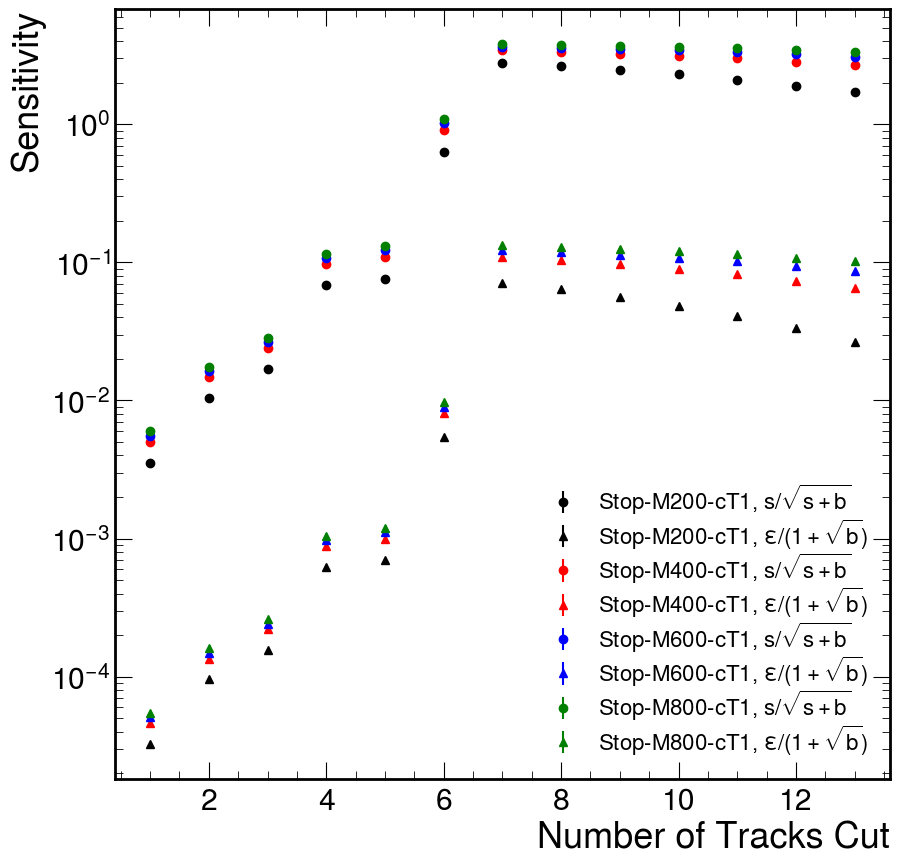

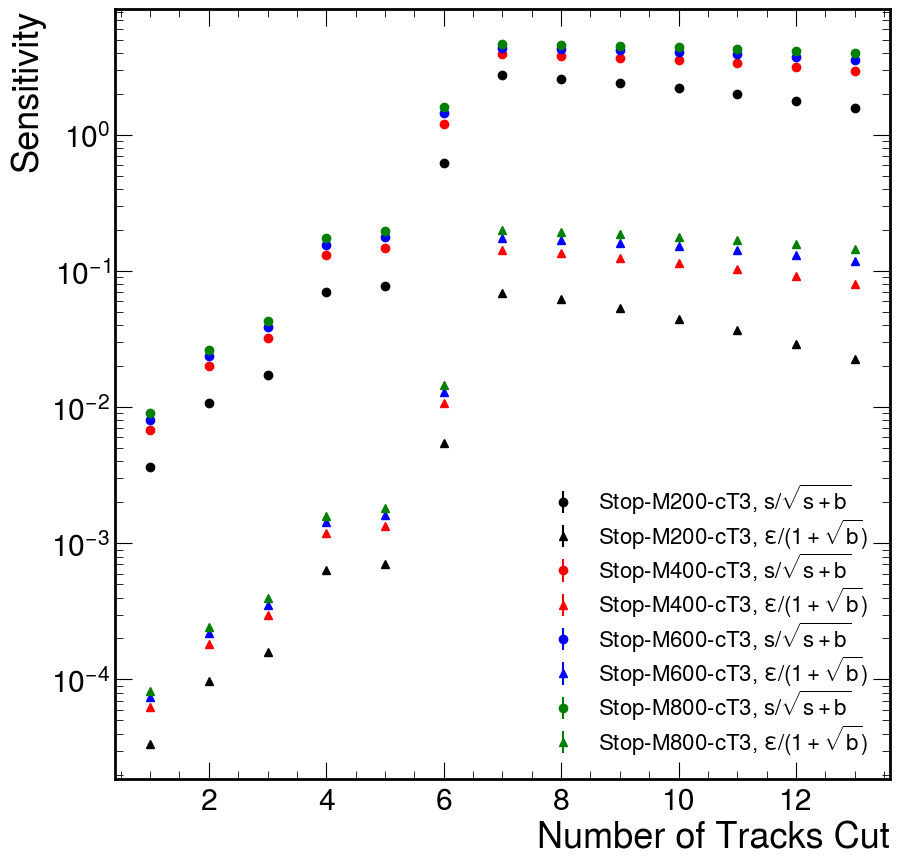

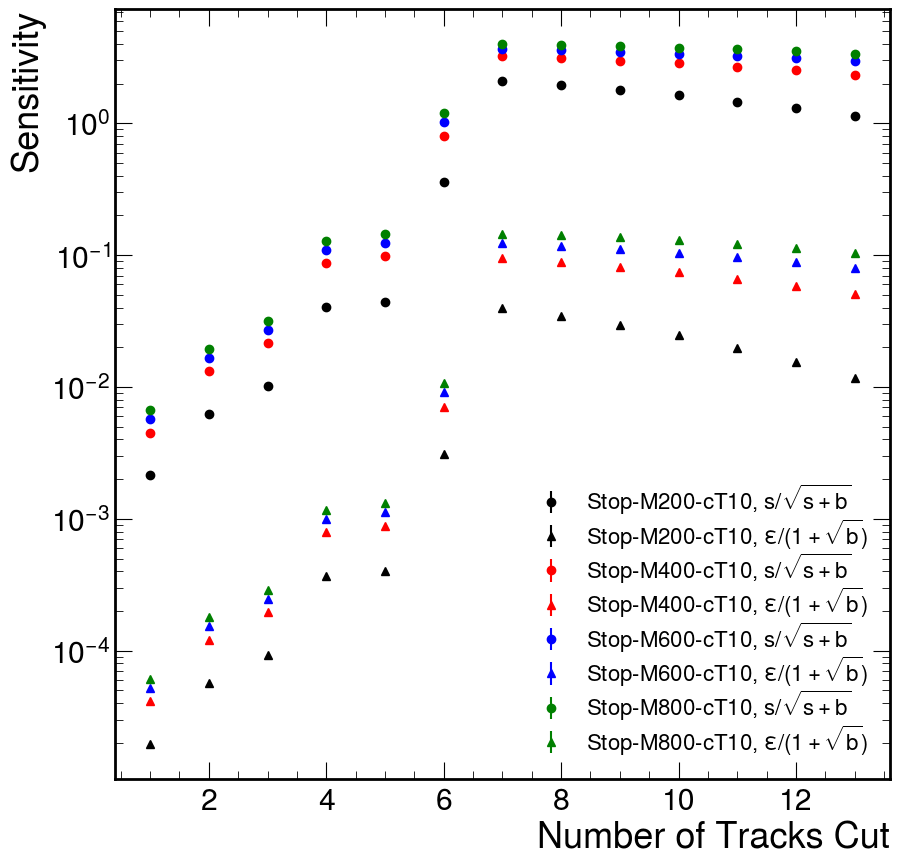

Total runtime: 4.12 seconds
best traditional sensitivity for signal Stop-M200-cT1 is 2.7726762041992856 requiring > 7.0 tracks and < 0.002000 uncertainty
best traditional sensitivity for signal Stop-M400-cT1 is 3.4380198952301293 requiring > 7.0 tracks and < 0.002000 uncertainty
best traditional sensitivity for signal Stop-M600-cT1 is 3.6544804281864294 requiring > 7.0 tracks and < 0.002000 uncertainty
best traditional sensitivity for signal Stop-M800-cT1 is 3.804933008608336 requiring > 7.0 tracks and < 0.002000 uncertainty
best traditional sensitivity for signal Stop-M200-cT3 is 2.7540344224427624 requiring > 7.0 tracks and < 0.002000 uncertainty
best traditional sensitivity for signal Stop-M400-cT3 is 3.9538903497432103 requiring > 7.0 tracks and < 0.002000 uncertainty
best traditional sensitivity for signal Stop-M600-cT3 is 4.38399981751775 requiring > 7.0 tracks and < 0.002000 uncertainty
best traditional sensitivity for signal Stop-M800-cT3 is 4.6634956138288635 requiring > 7.0 t

In [23]:
#Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

errCutValues = [0.002]
nTrackCutValues = np.linspace(1,13,13)
print(errCutValues)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","scoutVert_nTracks"]
        weightSum = np.zeros_like(nTrackCutValues)
        weightSumSquared = np.zeros_like(nTrackCutValues)
        
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # event weights

            dBVErr = batch["scoutVert_dBVErr"]
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            mask = dBVErr < errCutValue
            dBVErr = dBVErr[mask]
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            for i in range(len(nTrackCutValues)):
                mask = ntracks > nTrackCutValues[i]
                dBV = dBV[mask]
                dBVErr = dBVErr[mask]
                ntracks = ntracks[mask]
            
                mask = ak.sum(dBV>=0.1,axis=1)>0
                weights = weights[mask]
                dBV = dBV[mask]
                dBVErr = dBVErr[mask]
                ntracks = ntracks[mask]
                weightSum[i] += ak.sum(weights)
                weightSumSquared[i] += ak.sum(weights**2)
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
            
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, np.zeros_like(nTrackCutValues)) + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}
for errCutValue in errCutValues:
    print("errCutValue",errCutValue)
    bgPlotWeights = parallel_processing(processDict)
    sigPlotWeights = parallel_processing(signalDict)

    #Combining Background Subprocesses and Reweighting Events
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
    bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
    bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
    bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

    # **Plotting**
    for lifetime in ["1","3","10"]:
        fig, ax = plt.subplots()
        colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
        for signal, color in colors.items():
            sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
            if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
                bestTraditionalSensitivity[signal] = [np.max(sensitivity),errCutValue,nTrackCutValues[np.argmax(sensitivity)]]
            efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
            ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="o", color=color,label=signal+", s/$\sqrt{s+b}$")
            sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
            if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
                bestEfficiencySensitivity[signal] = [np.max(sensitivity),errCutValue,nTrackCutValues[np.argmax(sensitivity)]]
            ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="^", color=color,label=signal+", $\epsilon/(1+\sqrt{b})$")
            #sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))
            #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="x", color=color)

        ax.set_ylabel("Sensitivity")
        plt.xlabel("Number of Tracks Cut")
        ax.legend(labelspacing=0,prop={'size': 16})
        ax.set_yscale("log")
        plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")

[0.02  0.019 0.018 0.017 0.016 0.015 0.014 0.013 0.012 0.011 0.01  0.009
 0.008 0.007 0.006 0.005 0.004 0.003 0.002 0.001]
Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v11Scout20TrackFPR/250321_155620/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout20TrackFPR/250321_155626/TTtoLNu2Q.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v11Scout20TrackFPR/250321_155714/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v11Scout20TrackFPR/250321_155723/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400

/tmp/rmccarth/ipykernel_3788028/422724033.py:119: RuntimeWarning: divide by zero encountered in divide
  sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))


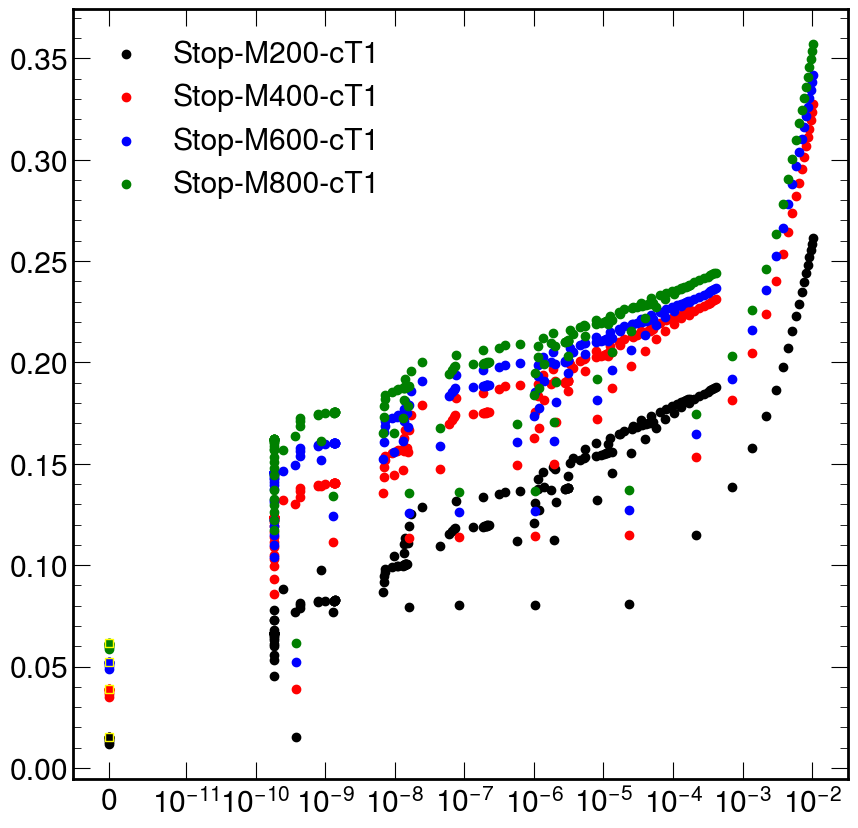

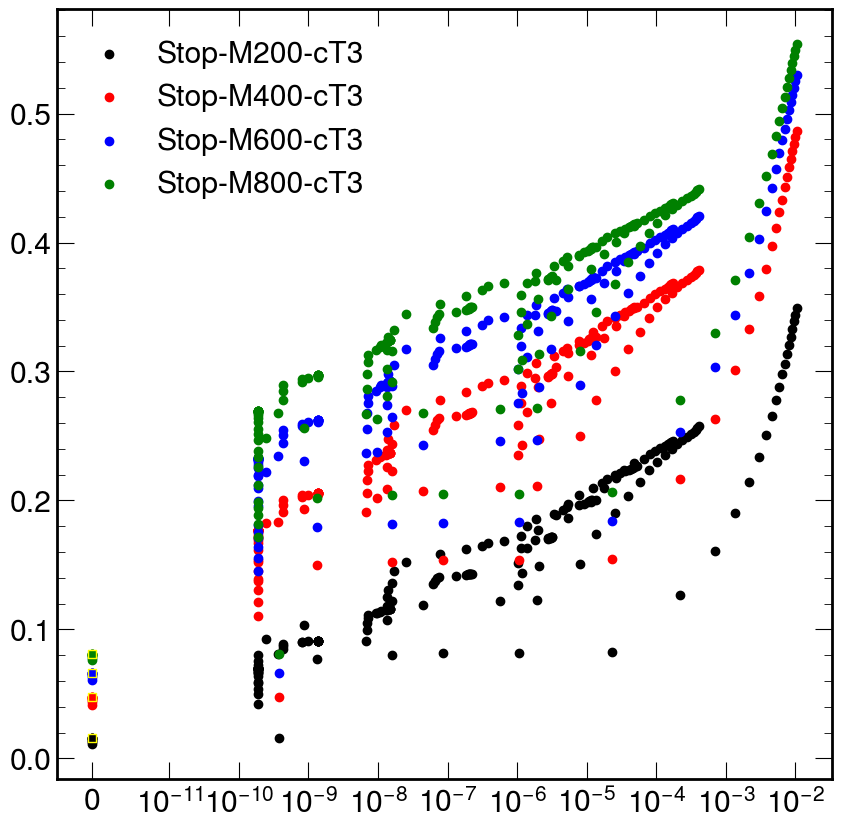

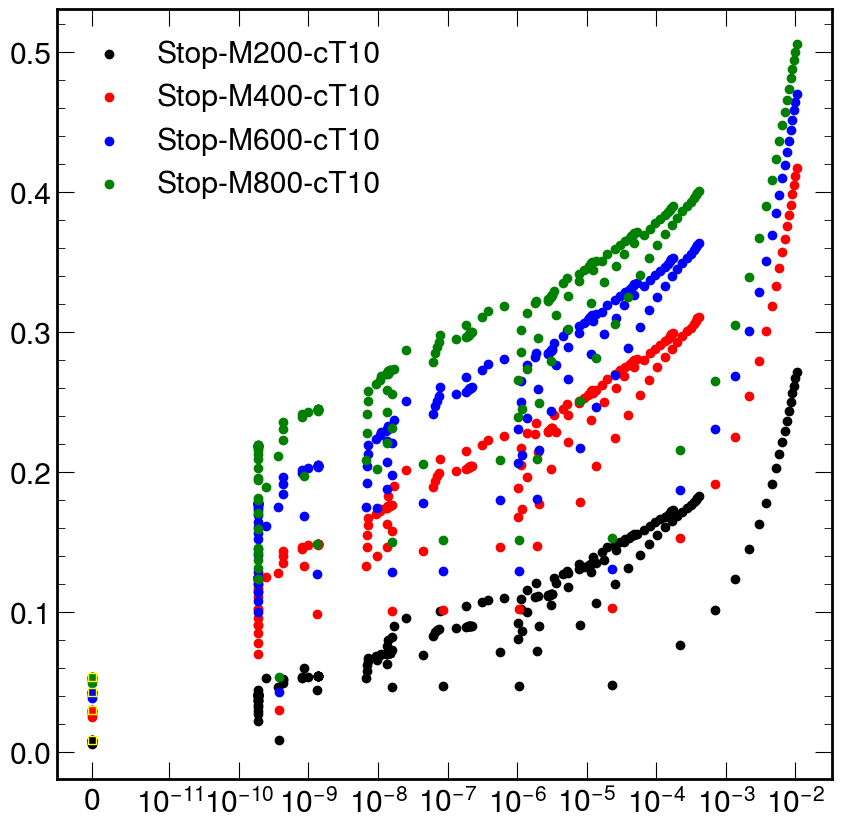

Total runtime: 13.51 seconds
best traditional sensitivity for signal Stop-M200-cT1 is 1.2972380917420956 requiring > 2.0 tracks and < 0.001000 uncertainty
best traditional sensitivity for signal Stop-M400-cT1 is 2.062473854379795 requiring > 2.0 tracks and < 0.001000 uncertainty
best traditional sensitivity for signal Stop-M600-cT1 is 2.3871757371421745 requiring > 2.0 tracks and < 0.001000 uncertainty
best traditional sensitivity for signal Stop-M800-cT1 is 2.587163079513919 requiring > 2.0 tracks and < 0.001000 uncertainty
best traditional sensitivity for signal Stop-M200-cT3 is 1.3045900505522814 requiring > 2.0 tracks and < 0.001000 uncertainty
best traditional sensitivity for signal Stop-M400-cT3 is 2.4660927797956713 requiring > 10.0 tracks and < 0.020000 uncertainty
best traditional sensitivity for signal Stop-M600-cT3 is 3.087669794491048 requiring > 10.0 tracks and < 0.020000 uncertainty
best traditional sensitivity for signal Stop-M800-cT3 is 3.4741200531606773 requiring > 10

In [4]:
#Improved Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

#Cuts need to go from loosest to tightest
errCutValues = np.linspace(0.001,0.02,20)[::-1]
nTrackCutValues = np.linspace(1,10,10)
print(errCutValues)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","scoutVert_nTracks"]
        weightSum = np.zeros((len(errCutValues),len(nTrackCutValues)))
        weightSumSquared = np.zeros((len(errCutValues),len(nTrackCutValues)))
        
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            dBVErr = batch["scoutVert_dBVErr"]
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            for i in range(len(errCutValues)):
                mask = dBVErr < errCutValues[i]
                dBVErr = dBVErr[mask]
                dBV = dBV[mask]
                ntracks = ntracks[mask]
                for j in range(len(nTrackCutValues)):
                    mask = ntracks > nTrackCutValues[j]
                    dBVMasked = dBV[mask]
                    dBVErrMasked = dBVErr[mask]
                    ntracksMasked = ntracks[mask]
            
                    mask = ak.sum(dBVMasked>=0.1,axis=1)>0
                    weightsMasked = weights[mask]
                    dBVMasked = dBVMasked[mask]
                    dBVErrMasked = dBVErrMasked[mask]
                    ntracksMasked = ntracksMasked[mask]
                    weightSum[i][j] += ak.sum(weightsMasked)
                    weightSumSquared[i][j] += ak.sum(weightsMasked**2)
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
            
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for lifetime in ["1","3","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
        if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestTraditionalSensitivity[signal] = [np.max(sensitivity),errCutValues[ind[0]],nTrackCutValues[ind[1]]]
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="o", color=color,label=signal)
        sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
        if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestEfficiencySensitivity[signal] = [np.max(sensitivity),errCutValues[ind[0]],nTrackCutValues[ind[1]]]
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="^", color=color)
        sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="x", color=color)
        ax.scatter(fpr,efficiency,label=signal,color=color,zorder=1)
        ax.scatter(fpr[ind],efficiency[ind],marker="s",color=color,zorder=2,edgecolor="yellow")
    #ax.set_ylabel("Sensitivity")
    #plt.xlabel("Number of Tracks Cut")
    plt.legend()
    #ax.set_xscale("log")
    plt.xscale("symlog",linthresh=10**-11)
    plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")

Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v10Reco/250304_230017/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v10Reco/250304_225938/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v10Reco/250304_225932/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v10Reco/250304_230025/QCD-4Jets_Bin-HT-400to600.root

Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v10Reco/250304_230040/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgr

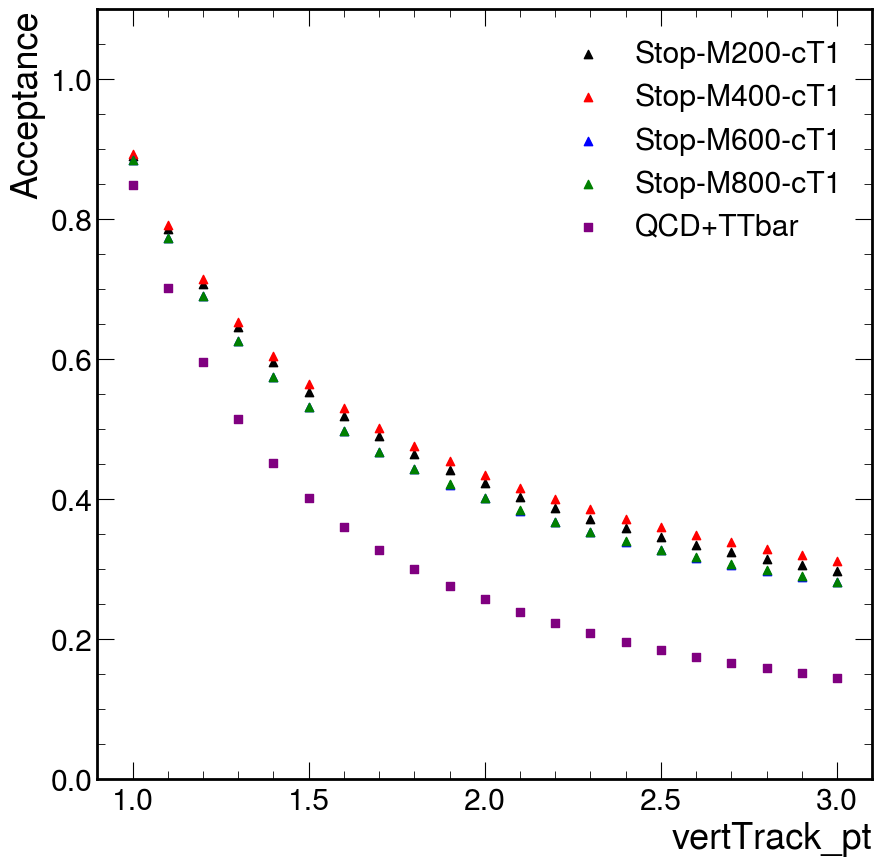

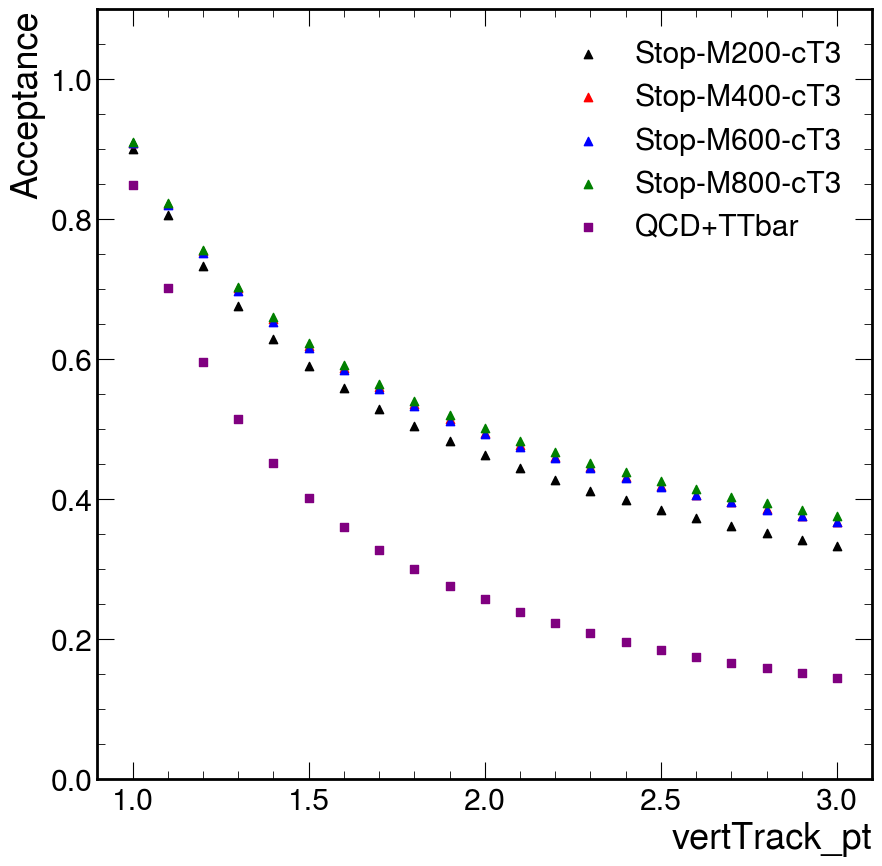

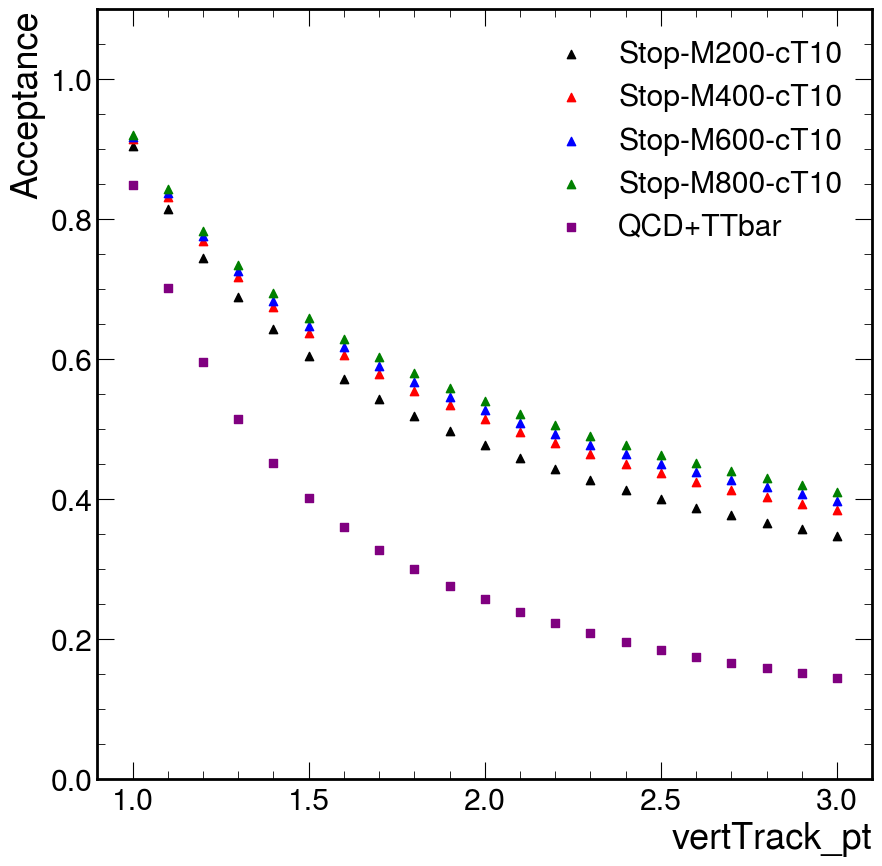

Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v10Reco/250304_230032/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v10Reco/250304_230017/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v10Reco/250304_225938/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v10Reco/250304_230025/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v10Reco/250304_225945/QCD-4Jets_Bin-HT-1000to1200.rootProcessing /eos/cms/store/group/phys_exoti

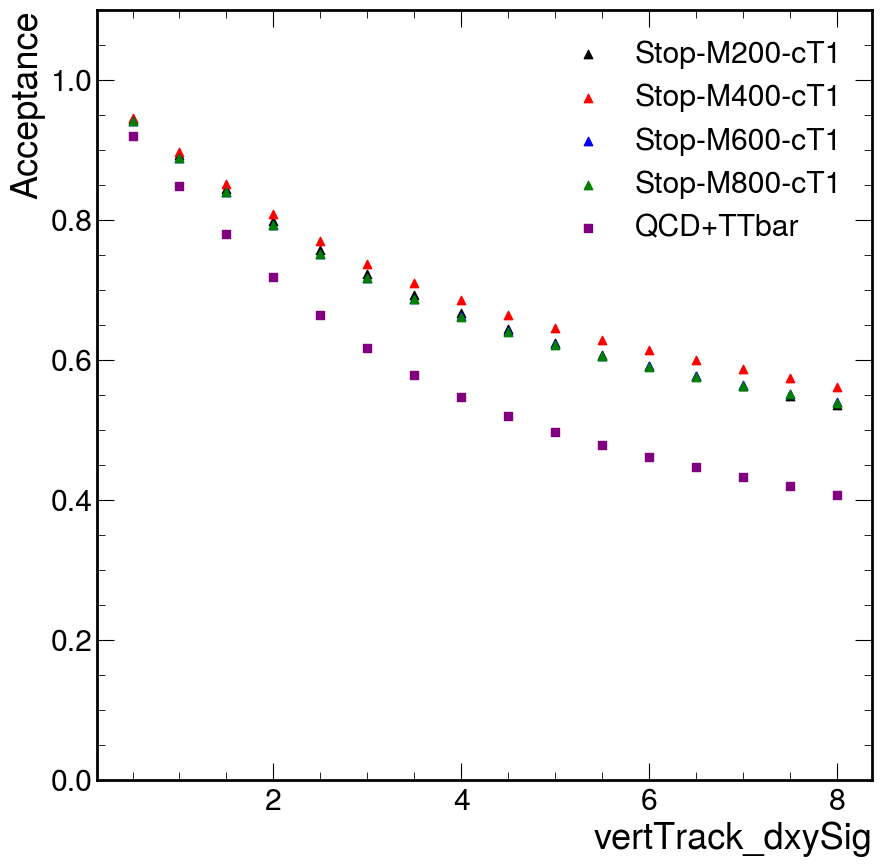

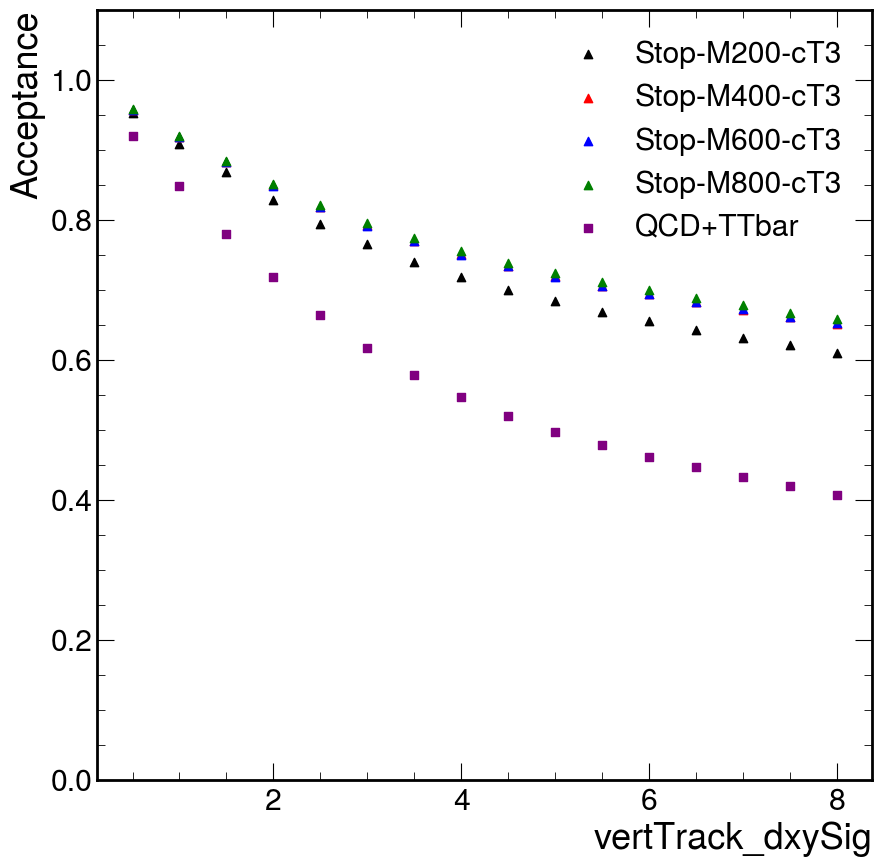

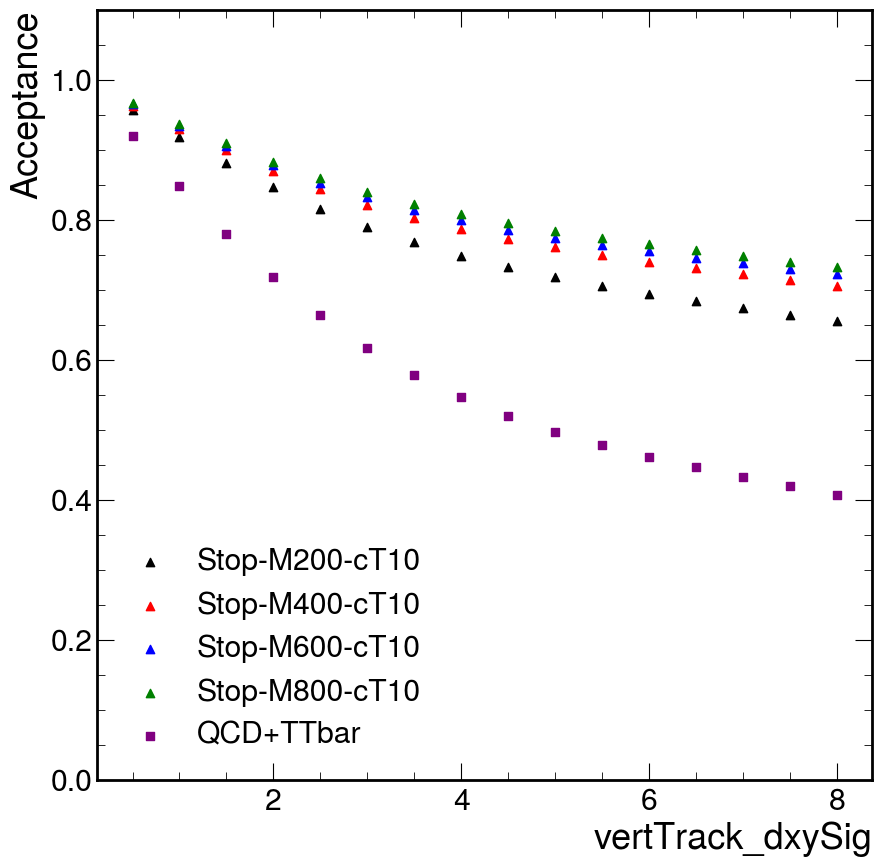

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v10Reco/250304_225932/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v10Reco/250304_230017/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v10Reco/250304_225952/QCD-4Jets_Bin-HT-1200to1500.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v10Reco/250304_230032/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v10Reco/250304_230040/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVS

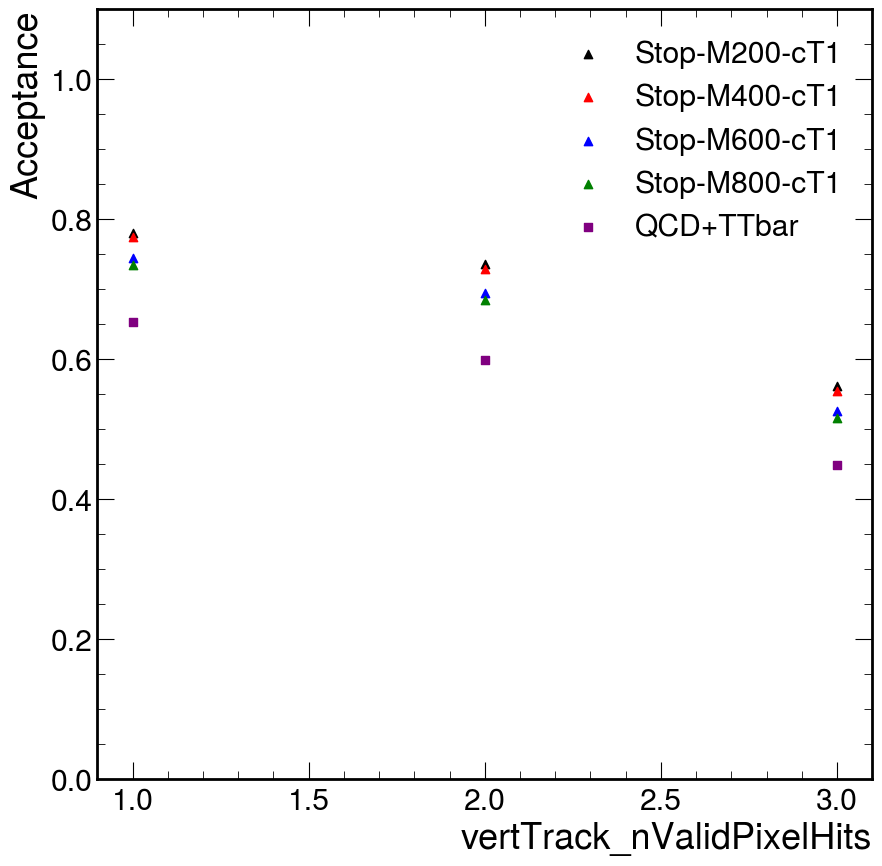

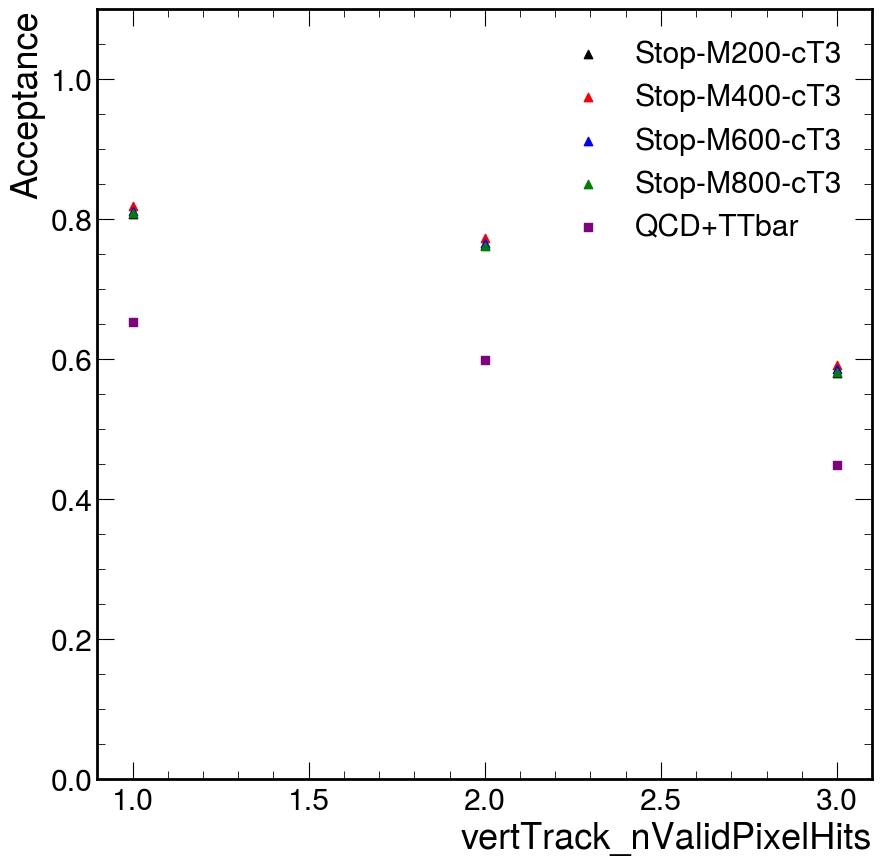

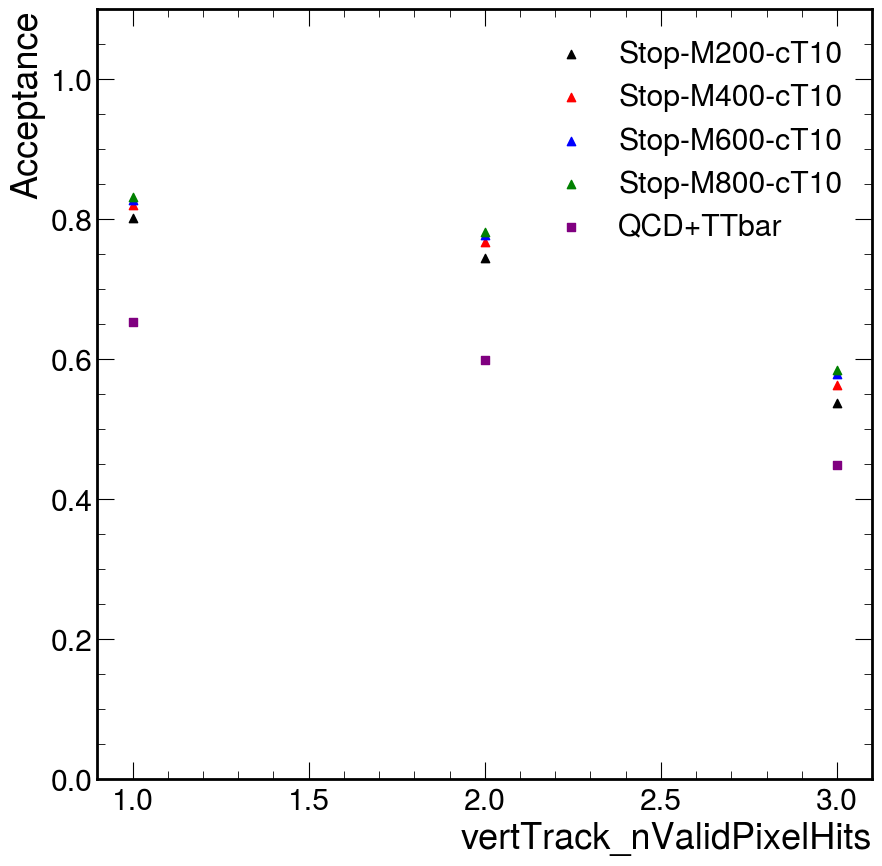

Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v10Reco/250304_230025/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v10Reco/250304_225932/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v10Reco/250304_230032/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v10Reco/250304_230017/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v10Reco/250304_225938/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM

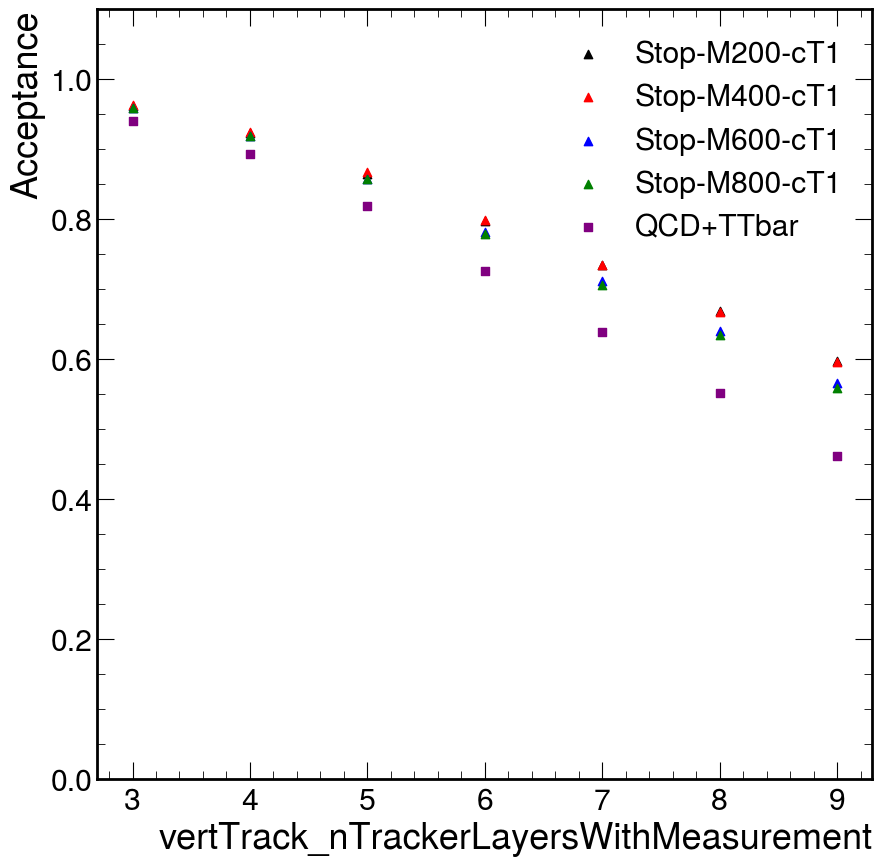

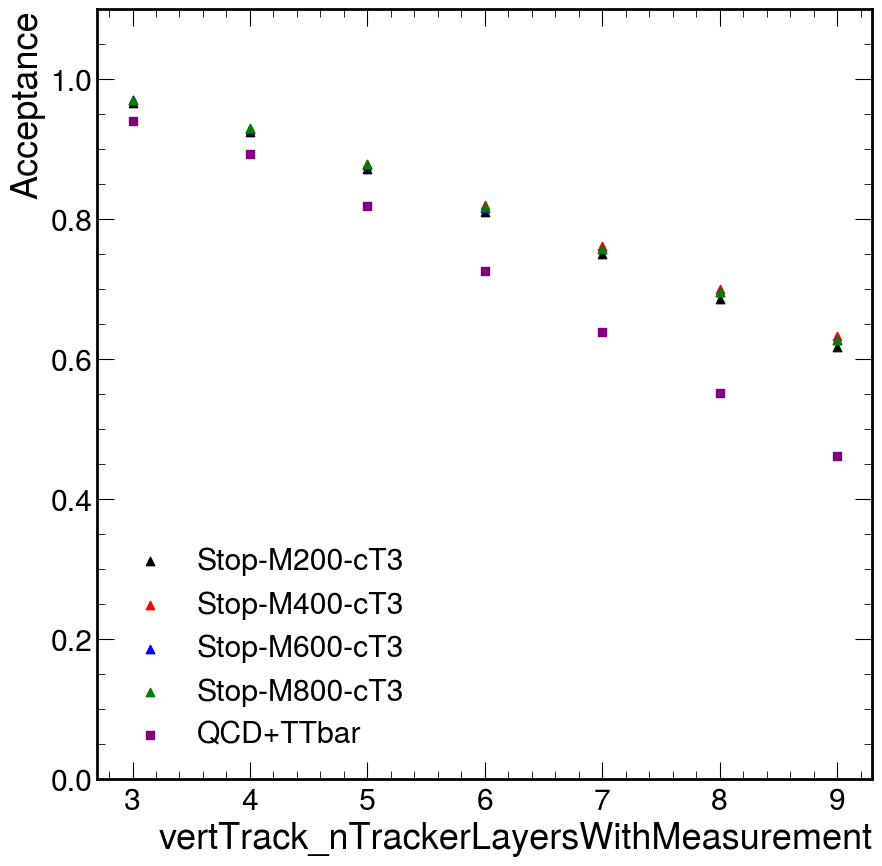

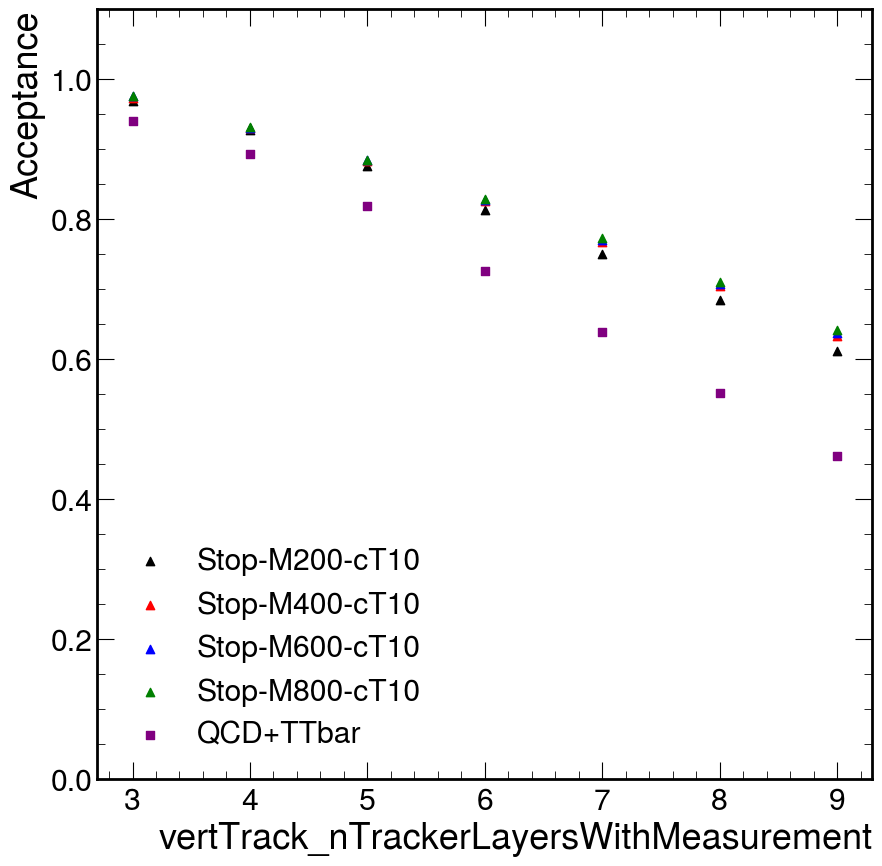

Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v10Reco/250304_230017/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v10Reco/250304_230032/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v10Reco/250304_225938/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v10Reco/250304_225932/TTto4Q.root

Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v10Reco/250304_225945/QCD-4Jets_Bin-HT-1000to1200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraph

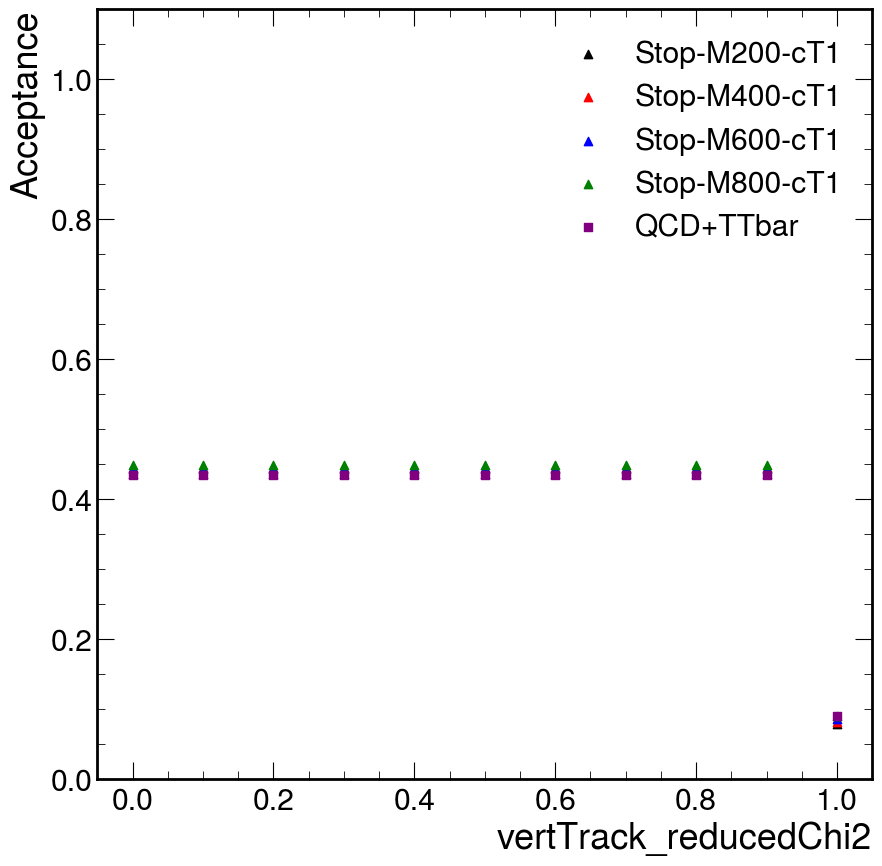

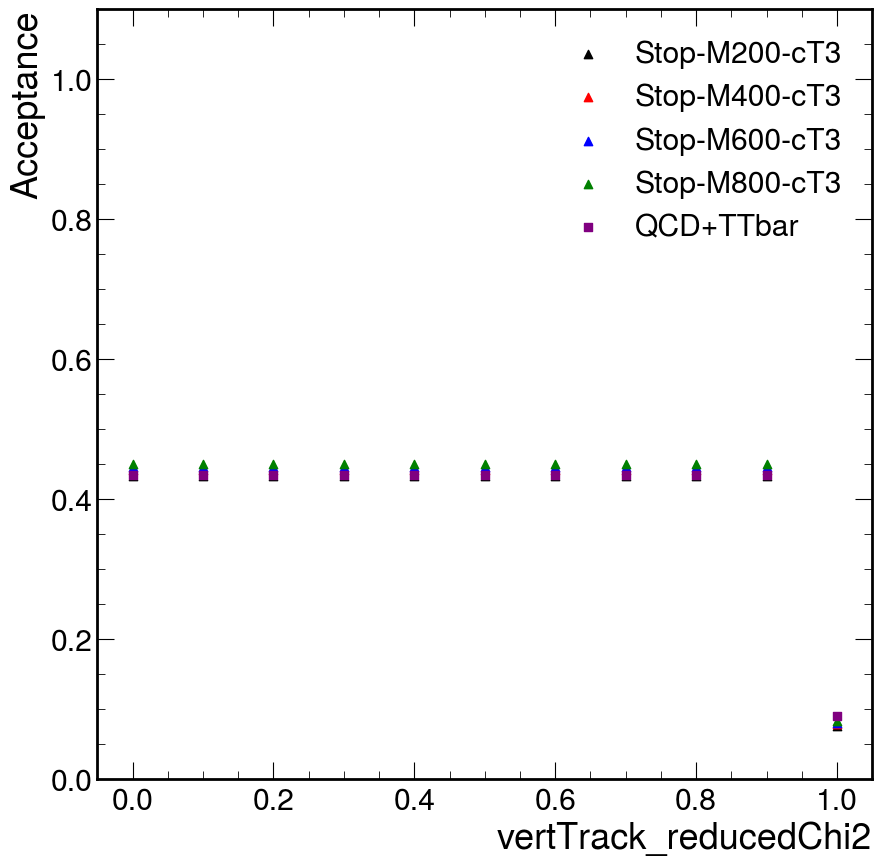

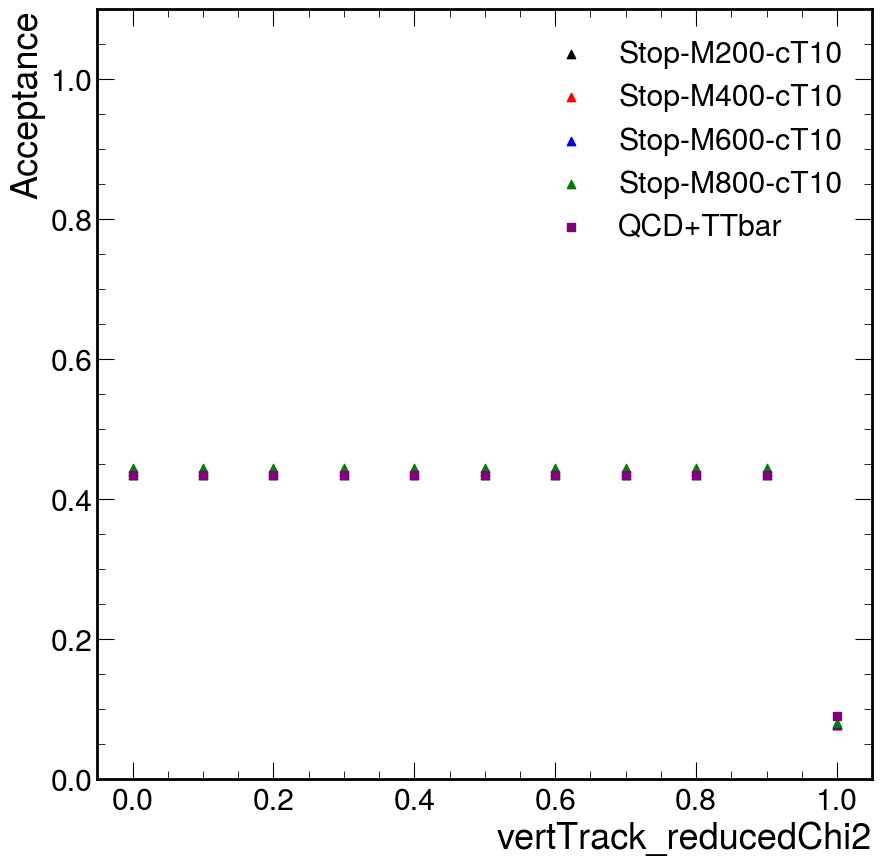

Total runtime: 3230.83 seconds


In [8]:
#Track Cut Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

ptTrackCuts = np.linspace(1,3,21)
#dxySigCuts = np.linspace(4,8,9)
#pixelHitsCuts = np.linspace(1,3,3)
#nTrackerLayersCuts = np.linspace(5,9,5)

cutDict = {"vertTrack_pt": np.linspace(1,3,21), "vertTrack_dxySig": np.linspace(0.5,8,16), "vertTrack_nValidPixelHits": np.linspace(1,3,3), "vertTrack_nTrackerLayersWithMeasurement": np.linspace(3,9,7), "vertTrack_reducedChi2": np.linspace(0,1,11)}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight",branch,"vertTrack_iVtx","scoutVert_dBV"]
        #weightSum = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSum = np.zeros((len(cuts)))
        #weightSumSquared = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSumSquared = np.zeros((len(cuts)))
        weightSkimSum = 0
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            data = batch[branch]
            if "vertTrack" in branch:
                mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
            data = data[mask]
            #dxySig = batch["vertTrack_dxySig"]
            #npixel = batch["vertTrack_nValidPixelHits"]
            #ntracker = batch["vertTrack_nTrackerLayersWithMeasurement"]
            nTracks = ak.num(data,axis=1)
            weightSkimSum += ak.sum(nTracks*weights)
            masks = [(data > cuts[i]) for i in range(len(cuts))]
            #dxyMasks = [(dxySig > dxySigCuts[j]) for j in range(len(dxySigCuts))]
            #pixelMasks = [(npixel > pixelHitsCuts[k]) for k in range(len(pixelHitsCuts))]
            #trackerMasks = [(ntracker > nTrackerLayersCuts[l]) for l in range(len(nTrackerLayersCuts))]
            for i in range(len(cuts)):
            #for j in range(len(dxySigCuts)):
            #for k in range(len(pixelHitsCuts)):
            #for l in range(len(nTrackerLayersCuts)):
                mask = masks[i] #& dxyMasks[j] & pixelMasks[k] & trackerMasks[l]
                dataMasked = data[mask]
                nTracks = ak.num(dataMasked,axis=1)
                weightSum[i] += ak.sum(nTracks*weights)
                weightSumSquared[i] += ak.sum(nTracks*(weights**2))
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
        output["weightSkimSum"] = {process: weightSkimSum}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

for branch, cuts in cutDict.items():

    bgPlotWeights = parallel_processing(processDict)
    sigPlotWeights = parallel_processing(signalDict)

    #Combining Background Subprocesses and Reweighting Events
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
    bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
    bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
    bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
    bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
    bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

    # **Plotting**
    for lifetime in ["1","3","10"]:
        fig, ax = plt.subplots()
        colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
        for signal, color in colors.items():
            efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
            ax.scatter(cuts,efficiency,label=signal,color=color,marker="^")
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        ax.scatter(cuts,fpr,label="QCD+TTbar",color="purple",marker="s")
        ax.set_ylabel("Acceptance")
        plt.xlabel(branch)
        plt.legend()
        ax.set_ylim(0.0,1.1)
        #plt.xscale("symlog",linthresh=10**-11)
        plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v10Scouting/250304_164853/TTto4Q.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v10Scouting/250304_164943/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v10Scouting/250304_165009/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v10Scouting/250304_164952/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v10Scouting/250304_164926/QCD-4Jets_Bin-HT-1500to2000.rootProcessing /eos/cms/store/g

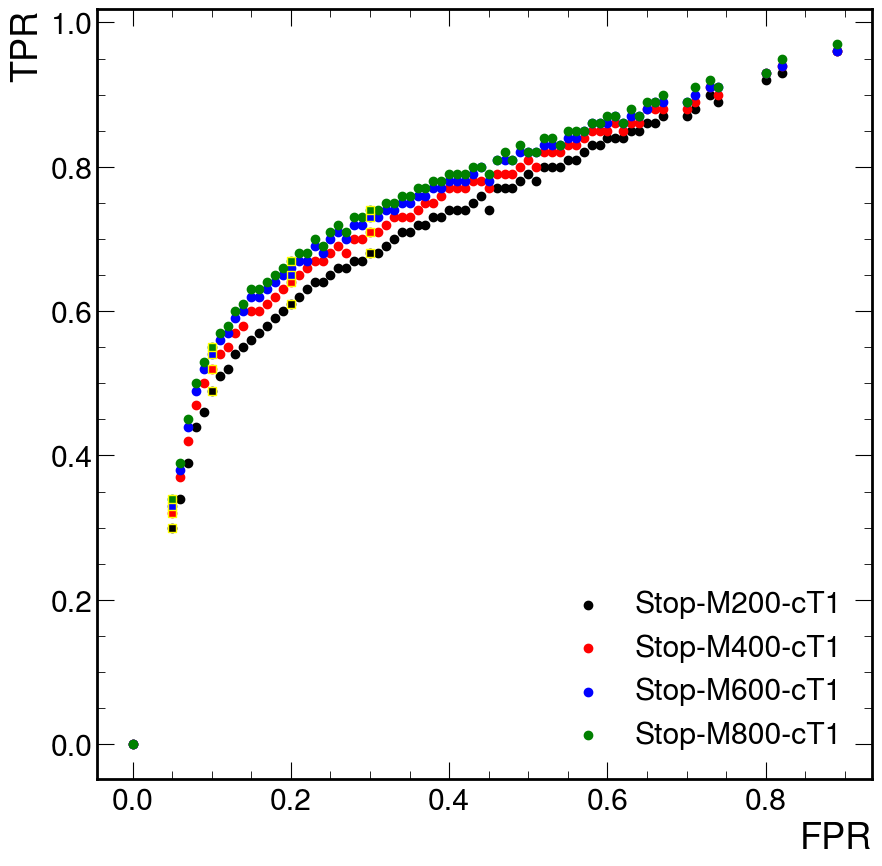

[(7, 15, 2, 6), (1, 15, 0, 3), (0, 12, 1, 2), (0, 10, 0, 2), (0, 9, 1, 1), (0, 6, 1, 2)]
[(7, 15, 2, 6), (1, 15, 0, 3), (0, 11, 1, 3), (0, 10, 0, 2), (0, 8, 0, 2), (0, 6, 1, 2)]
[(8, 15, 2, 5), (1, 15, 0, 3), (0, 12, 1, 2), (0, 10, 0, 2), (0, 8, 0, 2), (0, 6, 1, 2)]
[(8, 15, 2, 5), (1, 15, 0, 3), (0, 12, 1, 2), (0, 10, 0, 2), (0, 8, 0, 2), (0, 6, 1, 2)]


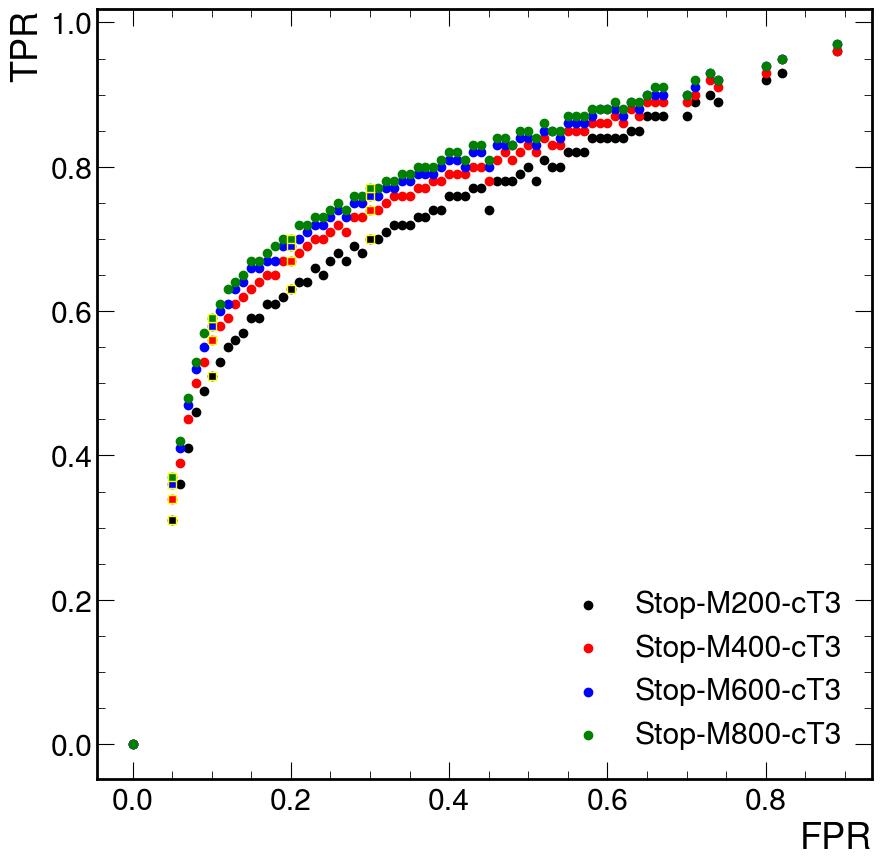

[(7, 15, 2, 6), (1, 15, 0, 3), (0, 12, 1, 2), (0, 10, 0, 2), (0, 8, 0, 2), (0, 6, 1, 2)]
[(8, 15, 2, 5), (2, 15, 1, 2), (0, 12, 1, 2), (0, 10, 0, 2), (0, 8, 0, 2), (0, 6, 1, 2)]
[(7, 15, 2, 6), (2, 15, 1, 2), (0, 12, 1, 2), (0, 10, 0, 2), (0, 8, 0, 2), (0, 6, 1, 2)]
[(7, 15, 2, 6), (2, 15, 1, 2), (0, 12, 1, 2), (0, 10, 0, 2), (0, 9, 1, 1), (0, 6, 1, 2)]


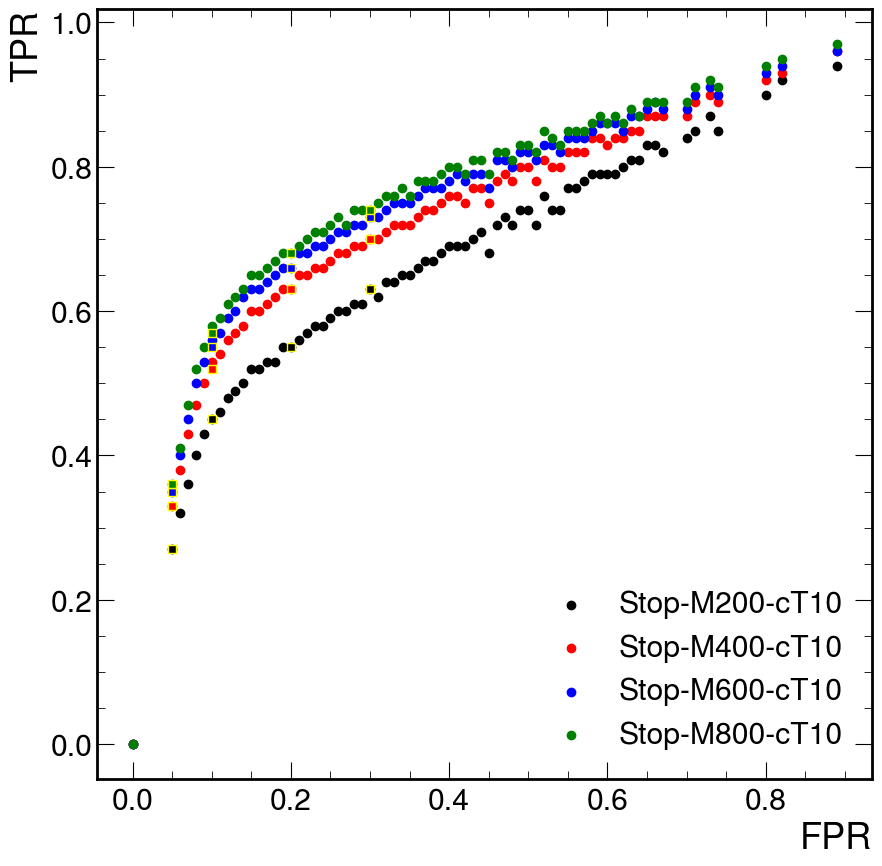

Total runtime: 224.57 seconds


In [22]:
#Track Cut Grid Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

ptTrackCuts = np.linspace(1,3,21)
dxySigCuts = np.linspace(0.5,8,16)
pixelHitsCuts = np.linspace(1,3,3)
nTrackerLayersCuts = np.linspace(3,9,7)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","vertTrack_iVtx","scoutVert_dBV","vertTrack_pt","vertTrack_dxySig","vertTrack_nValidPixelHits", "vertTrack_nTrackerLayersWithMeasurement"]
        weightSum = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSumSquared = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSkimSum = 0
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
            pt = batch["vertTrack_pt"][mask]
            dxySig = batch["vertTrack_dxySig"][mask]
            npixel = batch["vertTrack_nValidPixelHits"][mask]
            ntracker = batch["vertTrack_nTrackerLayersWithMeasurement"][mask]
            nTracks = ak.num(pt,axis=1)
            weightSkimSum += ak.sum(nTracks*weights)
            ptMasks = [(pt > ptTrackCuts[i]) for i in range(len(ptTrackCuts))]
            dxyMasks = [(dxySig > dxySigCuts[j]) for j in range(len(dxySigCuts))]
            pixelMasks = [(npixel > pixelHitsCuts[k]) for k in range(len(pixelHitsCuts))]
            trackerMasks = [(ntracker > nTrackerLayersCuts[l]) for l in range(len(nTrackerLayersCuts))]
            for i in range(len(cuts)):
                for j in range(len(dxySigCuts)):
                    for k in range(len(pixelHitsCuts)):
                        for l in range(len(nTrackerLayersCuts)):
                            mask = ptMasks[i] & dxyMasks[j] & pixelMasks[k] & trackerMasks[l]
                            ptMasked = pt[mask]
                            nTracks = ak.num(ptMasked,axis=1)
                            weightSum[i][j][k][l] += ak.sum(nTracks*weights)
                            weightSumSquared[i][j][k][l] += ak.sum(nTracks*(weights**2))
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
        output["weightSkimSum"] = {process: weightSkimSum}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()


bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for lifetime in ["1","3","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        efficiency = np.round(efficiency,2)
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        fpr = np.round(fpr,2)
        unique_fpr = np.unique(fpr)
        max_effs = np.array([])
        thresh = [True,True,True,True,True,True]
        thresh_val = [0.05,0.1,0.15,0.2,0.25,0.3]
        indices = []
        for ux in unique_fpr:
            unique_eff = np.where(fpr == ux, efficiency, -1)
            max_eff = np.max(unique_eff)
            ind = np.unravel_index(np.argmax(unique_eff, axis=None), unique_eff.shape)
            if(ux>=thresh_val[0] and thresh[0]): 
                indices.append(ind)
                thresh[0] = False
            if(ux>=thresh_val[1] and thresh[1]): 
                indices.append(ind)
                thresh[1] = False
            if(ux>=thresh_val[2] and thresh[2]): 
                indices.append(ind)
                thresh[2] = False
            if(ux>=thresh_val[3] and thresh[3]): 
                indices.append(ind)
                thresh[3] = False
            if(ux>=thresh_val[4] and thresh[4]): 
                indices.append(ind)
                thresh[4] = False
            if(ux>=thresh_val[5] and thresh[5]): 
                indices.append(ind)
                thresh[5] = False
            max_effs = np.append(max_effs,max_eff)
        print(indices)
        ax.scatter(unique_fpr,max_effs,label=signal,color=color,zorder=1)
        indices = [(8, 15, 2, 5),(1, 15, 0, 3),(0, 10, 0, 2),(0, 6, 1, 2)]
        for index in indices:
            ax.scatter(fpr[index],efficiency[index],color=color,marker="s",zorder=2,edgecolor="yellow")
        
    ax.set_ylabel("TPR")
    plt.xlabel("FPR")
    plt.legend()
    plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v11Scout30TrackFPR/250323_123549/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout30TrackFPR/250323_123555/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v11Scout30TrackFPR/250323_123630/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v11Scout30TrackFPR/250323_123652/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v11Scout30TrackFPR/250323_123609/QCD-4Jets_Bin-HT-1200to1500.rootProcessing /eos/cms/store/group/phys_exotica/D

/tmp/rmccarth/ipykernel_181727/711788286.py:162: RuntimeWarning: invalid value encountered in divide
  sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])


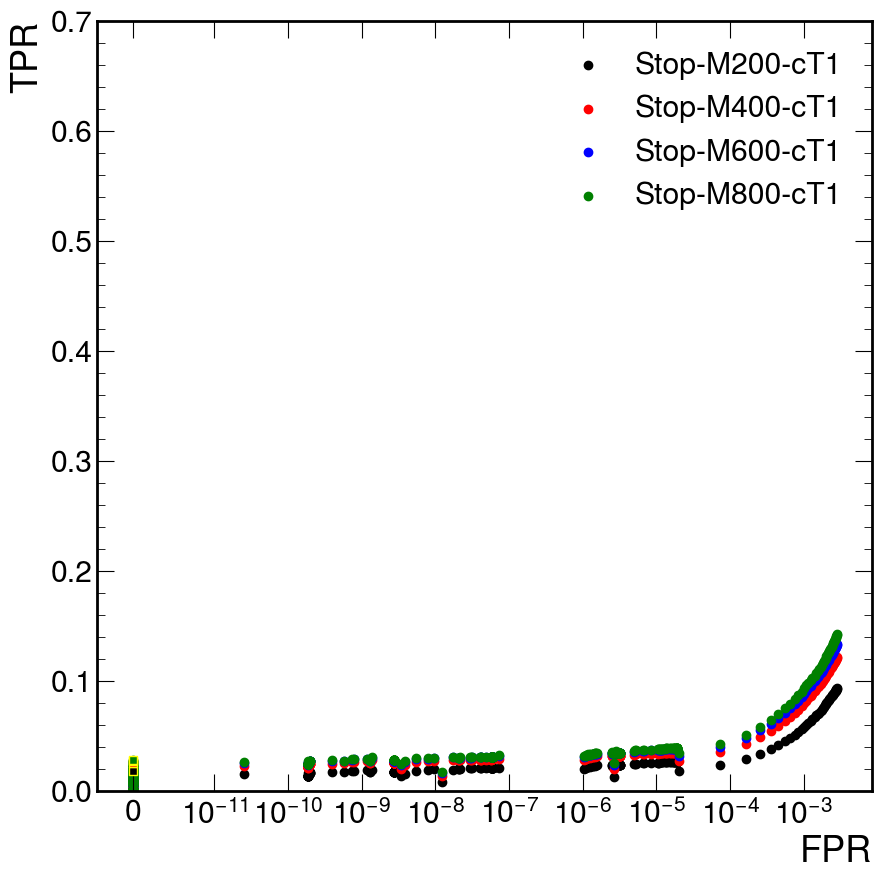

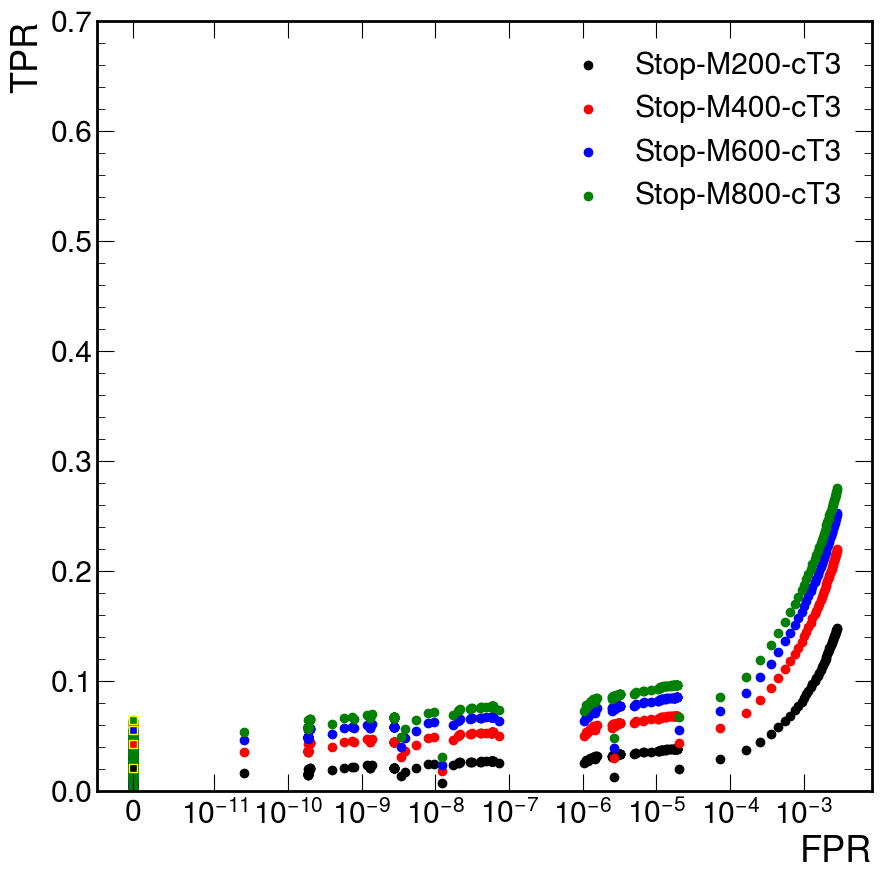

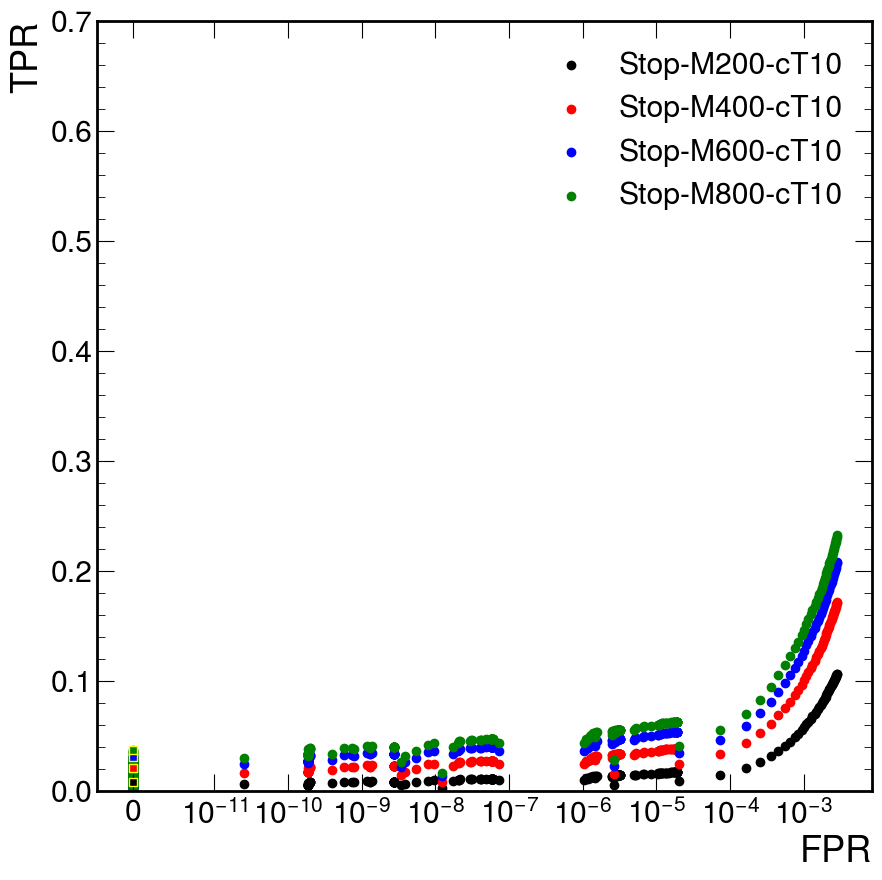

Total runtime: 118.43 seconds
total background: 226215788366.40002
best traditional sensitivity for signal Stop-M200-cT1 is 0 sig eff: 0 fpr: 0 requiring > 0 tracks and < 0.000000 uncertainty
best traditional sensitivity for signal Stop-M400-cT1 is 1.656385462384876 sig eff: 0.025179999999999637 fpr: 0.0 requiring > 4.0 tracks and < 0.009000 uncertainty
best traditional sensitivity for signal Stop-M600-cT1 is 1.724073316306474 sig eff: 0.027280000000000044 fpr: 0.0 requiring > 4.0 tracks and < 0.009000 uncertainty
best traditional sensitivity for signal Stop-M800-cT1 is 1.7354118819461883 sig eff: 0.027640000000000112 fpr: 0.0 requiring > 4.0 tracks and < 0.009000 uncertainty
best traditional sensitivity for signal Stop-M200-cT3 is 0 sig eff: 0 fpr: 0 requiring > 0 tracks and < 0.000000 uncertainty
best traditional sensitivity for signal Stop-M400-cT3 is 2.156364118701936 sig eff: 0.042675350701405816 fpr: 0.0 requiring > 4.0 tracks and < 0.009000 uncertainty
best traditional sensitivi

In [6]:
#Vertex and Track Cut Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

#ptTrackCuts = np.linspace(1,3,21)
#dxySigCuts = np.linspace(0.5,8,16)
#pixelHitsCuts = np.linspace(1,3,3)
#nTrackerLayersCuts = np.linspace(3,9,7)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#30% fpr cuts
ptTrackCuts = np.linspace(1,1,1)
dxySigCuts = np.linspace(3.5,3.5,1)
pixelHitsCuts = np.linspace(2,2,1)
nTrackerLayersCuts = np.linspace(5,5,1)
errCuts = np.linspace(0.001,0.05,50)[::-1]
nTrackCuts = np.linspace(1,13,13)

#25% fpr cuts
#ptTrackCuts = np.linspace(1,1,1)
#dxySigCuts = np.linspace(4.5,4.5,1)
#pixelHitsCuts = np.linspace(1,1,1)
#nTrackerLayersCuts = np.linspace(5,5,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#20% fpr cuts
#ptTrackCuts = np.linspace(1,1,1)
#dxySigCuts = np.linspace(5.5,5.5,1)
#pixelHitsCuts = np.linspace(1,1,1)
#nTrackerLayersCuts = np.linspace(5,5,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#15% fpr cuts
#ptTrackCuts = np.linspace(1,1,1)
#dxySigCuts = np.linspace(6.0,6.0,1)
#pixelHitsCuts = np.linspace(2,2,1)
#nTrackerLayersCuts = np.linspace(6,6,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#10% fpr cuts
#ptTrackCuts = np.linspace(1.1,1.1,1)
#dxySigCuts = np.linspace(8.0,8.0,1)
#pixelHitsCuts = np.linspace(1,1,1)
#nTrackerLayersCuts = np.linspace(6,6,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","vertTrack_iVtx","vertTrack_pt","vertTrack_dxySig","vertTrack_nValidPixelHits", "vertTrack_nTrackerLayersWithMeasurement"]
        weightSum = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts),len(errCuts),len(nTrackCuts)))
        weightSumSquared = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts),len(errCuts),len(nTrackCuts)))
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights   
            mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
            pt = batch["vertTrack_pt"][mask]
            dxySig = batch["vertTrack_dxySig"][mask]
            npixel = batch["vertTrack_nValidPixelHits"][mask]
            ntracker = batch["vertTrack_nTrackerLayersWithMeasurement"][mask]
            ivtx = batch["vertTrack_iVtx"][mask]
            
            ptMasks = [(pt > ptTrackCuts[i]) for i in range(len(ptTrackCuts))]
            dxyMasks = [(dxySig > dxySigCuts[j]) for j in range(len(dxySigCuts))]
            pixelMasks = [(npixel > pixelHitsCuts[k]) for k in range(len(pixelHitsCuts))]
            trackerMasks = [(ntracker > nTrackerLayersCuts[l]) for l in range(len(nTrackerLayersCuts))]
            
            dBV = batch["scoutVert_dBV"]
            dBVErr = batch["scoutVert_dBVErr"]
            dBVMask = (dBV >= 0.1)
            dBVErrMask = [(dBVErr < errCuts[m]) for m in range(len(errCuts))]
            
            for i in range(len(ptTrackCuts)):
                for j in range(len(dxySigCuts)):
                    for k in range(len(pixelHitsCuts)):
                        for l in range(len(nTrackerLayersCuts)):
                            mask = ptMasks[i] & dxyMasks[j] & pixelMasks[k] & trackerMasks[l]
                            ivtxMasked = ivtx[mask]
                            ntracks = ak.Array([
                                np.bincount(ind_event, minlength=len(dBV_event))
                                for ind_event, dBV_event in zip(ivtxMasked, dBV)
                            ])
                            ntrackMasks = [(ntracks > nTrackCuts[n]) for n in range(len(nTrackCuts))]
                            for m in range(len(errCuts)):
                                for n in range(len(nTrackCuts)):
                                    mask = dBVMask & dBVErrMask[m] & ntrackMasks[n]
                                    dBVMasked = dBV[mask]
                                    mask = ak.num(dBVMasked,axis=1)>1
                                    weightsMasked = weights[mask]
                                    weightSum[i][j][k][l][m][n] += ak.sum(weightsMasked)
                                    weightSumSquared[i][j][k][l][m][n] += ak.sum(weightsMasked**2)
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0,0,0,0,0,0,0], "Stop-M400-cT1": [0,0,0,0,0,0,0,0,0], "Stop-M600-cT1": [0,0,0,0,0,0,0,0,0], "Stop-M800-cT1": [0,0,0.0,0,0,0,0,0], "Stop-M200-cT3": [0,0,0,0,0,0,0,0,0], "Stop-M400-cT3": [0,0,0,0,0,0,0,0,0], "Stop-M600-cT3": [0,0,0,0,0,0,0,0,0], "Stop-M800-cT3": [0,0,0,0,0,0,0,0,0], "Stop-M200-cT10": [0,0,0,0,0,0,0,0,0], "Stop-M400-cT10": [0,0,0,0,0,0,0,0,0], "Stop-M600-cT10": [0,0,0,0,0,0,0,0,0], "Stop-M800-cT10": [0,0,0,0,0,0,0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0,0,0,0,0,0,0], "Stop-M400-cT1": [0,0,0,0,0,0,0,0,0], "Stop-M600-cT1": [0,0,0,0,0,0,0,0,0], "Stop-M800-cT1": [0,0,0.0,0,0,0,0,0], "Stop-M200-cT3": [0,0,0,0,0,0,0,0,0], "Stop-M400-cT3": [0,0,0,0,0,0,0,0,0], "Stop-M600-cT3": [0,0,0,0,0,0,0,0,0], "Stop-M800-cT3": [0,0,0,0,0,0,0,0,0], "Stop-M200-cT10": [0,0,0,0,0,0,0,0,0], "Stop-M400-cT10": [0,0,0,0,0,0,0,0,0], "Stop-M600-cT10": [0,0,0,0,0,0,0,0,0], "Stop-M800-cT10": [0,0,0,0,0,0,0,0,0]}

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for lifetime in ["1","3","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestTraditionalSensitivity[signal] = [np.max(sensitivity),efficiency[ind],fpr[ind],ptTrackCuts[ind[0]],dxySigCuts[ind[1]],pixelHitsCuts[ind[2]],nTrackerLayersCuts[ind[3]],errCuts[ind[4]],nTrackCuts[ind[5]]]
        sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
        if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestEfficiencySensitivity[signal] = [np.max(sensitivity),efficiency[ind],fpr[ind],ptTrackCuts[ind[0]],dxySigCuts[ind[1]],pixelHitsCuts[ind[2]],nTrackerLayersCuts[ind[3]],errCuts[ind[4]],nTrackCuts[ind[5]]]
        ax.scatter(fpr,efficiency,label=signal,color=color,zorder=1)
        ax.scatter(fpr[ind],efficiency[ind],marker="s",color=color,zorder=2,edgecolor="yellow")
        plt.xscale("symlog",linthresh=10**-11)
    ax.set_ylabel("TPR")
    ax.set_ylim(0.0,0.7)
    plt.xlabel("FPR")
    plt.legend()
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
print("total background:",bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"sig eff:",cuts[1],"fpr:",cuts[2],"requiring >",cuts[8],"tracks and <",f"{cuts[7]:3f}","uncertainty")# track selection of pt>",cuts[3],"dxySig>",cuts[4],"pixelHits>",cuts[5],"tracker layers>",cuts[6])
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"sig eff:",cuts[1],"fpr:",cuts[2],"requiring >",cuts[8],"tracks and <",f"{cuts[7]:3f}","uncertainty")# track selection of pt>",cuts[3],"dxySig>",cuts[4],"pixelHits>",cuts[5],"tracker layers>",cuts[6])


In [14]:
np.linspace(0.001,0.05,50)[::-1]

array([0.05 , 0.049, 0.048, 0.047, 0.046, 0.045, 0.044, 0.043, 0.042,
       0.041, 0.04 , 0.039, 0.038, 0.037, 0.036, 0.035, 0.034, 0.033,
       0.032, 0.031, 0.03 , 0.029, 0.028, 0.027, 0.026, 0.025, 0.024,
       0.023, 0.022, 0.021, 0.02 , 0.019, 0.018, 0.017, 0.016, 0.015,
       0.014, 0.013, 0.012, 0.011, 0.01 , 0.009, 0.008, 0.007, 0.006,
       0.005, 0.004, 0.003, 0.002, 0.001])